# Notebook 03 v2 — Probabilistic Forecasting and Scenario Generation

This notebook converts the frozen out-of-sample deterministic predictions from
Notebook 02 into calibrated probabilistic wind forecasts and joint DK1–DK2
scenarios.

Version 2 correctly permits missing predictions from sparse Notebook 02
baselines, audits them, and removes only those unusable rows before building
the probabilistic modelling dataset.


## Information-time design

For an evaluation fold \(f\), probabilistic calibration uses only residuals
from completed out-of-sample folds \(< f\).

Therefore:

- D2 fold 1 calibrates D2 fold 2;
- D2 folds 1–2 calibrate D2 fold 3;
- exact fold 1 calibrates exact fold 2;
- the first fold of each panel is reserved as calibration history and is not
  assigned probabilistic evaluation scores.

This avoids using future residuals or the current evaluation fold to estimate
its uncertainty distribution.


## Optional dependencies

The project environment should already contain these packages. Run the command
below only when a package is missing.

```python
# %pip install numpy pandas pyarrow scikit-learn scipy matplotlib
```


In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Any, Iterable, Sequence
import hashlib
import json
import math
import platform
import sys
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LOCAL_TIMEZONE = "Europe/Copenhagen"
TARGET_COLUMN = "actual_wind_mwh"
KEY_COLUMNS = (
    "panel",
    "fold_id",
    "timestamp_utc",
    "price_area",
)

NOTEBOOK_02_OUTPUT_RUN = "notebook_02_v5_full"
NOTEBOOK_03_OUTPUT_RUN = "notebook_03_probabilistic"

QUANTILE_LEVELS = (
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
)

CENTRAL_INTERVALS = (
    0.50,
    0.80,
    0.90,
)

PROVIDER_MAP = {
    "d2": (
        "gfs",
        "icon_eu",
        "ecmwf",
        "gem_global",
        "jma_gsm",
    ),
    "exact": (
        "gfs",
        "icon_eu",
        "ecmwf",
        "dmi",
        "arpege_europe",
        "ukmo_global",
        "cma_grapes",
    ),
}

# Deterministic centres retained from Notebook 02.
CANDIDATE_CENTRES = {
    ("d2", "DK1"): (
        "ensemble::linear_stack",
        "ensemble::hedge",
        "pooled_lightgbm",
    ),
    ("d2", "DK2"): (
        "pooled_lightgbm",
        "ensemble::equal_weight",
        "ensemble::hedge",
    ),
    ("exact", "DK1"): (
        "ensemble::hedge",
        "ensemble::dirichlet_mae",
        "pooled_lightgbm",
    ),
    ("exact", "DK2"): (
        "ensemble::hedge",
        "ensemble::inverse_mae",
        "pooled_lightgbm",
        "ensemble::equal_weight",
    ),
}

PRIMARY_CENTRES = {
    ("d2", "DK1"): "ensemble::linear_stack",
    ("d2", "DK2"): "pooled_lightgbm",
    ("exact", "DK1"): "ensemble::hedge",
    ("exact", "DK2"): "ensemble::hedge",
}

MIN_HISTORY_ROWS = 500
CONDITIONAL_MIN_COMBINATION_ROWS = 20
CONDITIONAL_MIN_HOUR_ROWS = 24
CONDITIONAL_MIN_REGIME_ROWS = 100

GBDT_MAX_ITER = 250
GBDT_LEARNING_RATE = 0.05
GBDT_MAX_LEAF_NODES = 15
GBDT_MIN_SAMPLES_LEAF = 30
GBDT_L2_REGULARIZATION = 1.0

CONFORMAL_TRAIN_FRACTION = 0.70
MIN_CONFORMAL_TRAIN_ROWS = 400
MIN_CONFORMAL_CALIBRATION_ROWS = 150

SCENARIO_COUNT = 250
SCENARIO_SCALE_LOWER = 0.60
SCENARIO_SCALE_UPPER = 1.80
ENERGY_SCORE_PAIR_DRAWS = 500

RUN_QUANTILE_GBDT = True
RUN_CONFORMAL_GBDT = True
RUN_SCENARIOS = True

print(
    {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "random_seed": RANDOM_SEED,
        "notebook_02_output_run": NOTEBOOK_02_OUTPUT_RUN,
        "notebook_03_output_run": NOTEBOOK_03_OUTPUT_RUN,
        "quantiles": QUANTILE_LEVELS,
        "scenario_count": SCENARIO_COUNT,
    }
)


{'python': '3.10.11', 'platform': 'Windows-10-10.0.17763-SP0', 'random_seed': 42, 'notebook_02_output_run': 'notebook_02_v5_full', 'notebook_03_output_run': 'notebook_03_probabilistic', 'quantiles': (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95), 'scenario_count': 250}


In [3]:
# ============================================================
# 2. PROJECT ROOT AND OUTPUT DIRECTORIES
# ============================================================

def find_project_root(
    starting_path: Path | None = None,
) -> Path:
    current = Path(starting_path or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (
            candidate.joinpath("pyproject.toml").exists()
            and candidate.joinpath("data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Expected pyproject.toml and data/."
    )


PROJECT_ROOT = find_project_root()

NOTEBOOK_02_DIR = (
    PROJECT_ROOT
    / "outputs"
    / NOTEBOOK_02_OUTPUT_RUN
)

NOTEBOOK_02_PREDICTION_DIR = (
    NOTEBOOK_02_DIR
    / "predictions"
)

NOTEBOOK_02_AUDIT_DIR = (
    NOTEBOOK_02_DIR
    / "audits"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / NOTEBOOK_03_OUTPUT_RUN
)

AUDIT_DIR = OUTPUT_DIR / "audits"
FIGURE_DIR = OUTPUT_DIR / "figures"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
SCENARIO_DIR = OUTPUT_DIR / "scenarios"
TABLE_DIR = OUTPUT_DIR / "tables"

for directory in (
    AUDIT_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    SCENARIO_DIR,
    TABLE_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("Notebook 02 inputs:", NOTEBOOK_02_DIR)
print("Notebook 03 outputs:", OUTPUT_DIR)


Project root: C:\Users\chka24ac\Nordic Wind Decision System
Notebook 02 inputs: C:\Users\chka24ac\Nordic Wind Decision System\outputs\notebook_02_v5_full
Notebook 03 outputs: C:\Users\chka24ac\Nordic Wind Decision System\outputs\notebook_03_probabilistic


In [4]:
# ============================================================
# 3. LOAD AND HASH NOTEBOOK 02 OUTPUTS
# ============================================================

def sha256_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


prediction_path = (
    NOTEBOOK_02_PREDICTION_DIR
    / "notebook_02_test_predictions.parquet"
)

verification_path = (
    NOTEBOOK_02_AUDIT_DIR
    / "notebook_02_verification.json"
)

if not prediction_path.exists():
    raise FileNotFoundError(
        f"Notebook 02 prediction file not found: {prediction_path}"
    )

if not verification_path.exists():
    raise FileNotFoundError(
        f"Notebook 02 verification file not found: {verification_path}"
    )

with verification_path.open(
    "r",
    encoding="utf-8",
) as file:
    notebook_02_verification = json.load(file)

if notebook_02_verification.get(
    "verification_status"
) != "MODELLING_COMPLETE":
    raise RuntimeError(
        "Notebook 02 is not verified as MODELLING_COMPLETE."
    )

all_test_predictions = pd.read_parquet(
    prediction_path
)

all_test_predictions["timestamp_utc"] = pd.to_datetime(
    all_test_predictions["timestamp_utc"],
    utc=True,
)

if "forecast_origin_utc" in all_test_predictions:
    all_test_predictions["forecast_origin_utc"] = pd.to_datetime(
        all_test_predictions["forecast_origin_utc"],
        utc=True,
        errors="coerce",
    )

input_manifest = {
    "prediction_path": str(prediction_path),
    "prediction_sha256": sha256_file(prediction_path),
    "prediction_shape": list(all_test_predictions.shape),
    "notebook_02_verification_path": str(verification_path),
    "notebook_02_verification_status": (
        notebook_02_verification.get(
            "verification_status"
        )
    ),
    "notebook_02_d2_folds": notebook_02_verification.get(
        "d2_folds"
    ),
    "notebook_02_exact_folds": notebook_02_verification.get(
        "exact_folds"
    ),
}

print(json.dumps(input_manifest, indent=2))


{
  "prediction_path": "C:\\Users\\chka24ac\\Nordic Wind Decision System\\outputs\\notebook_02_v5_full\\predictions\\notebook_02_test_predictions.parquet",
  "prediction_sha256": "48ca10cb88adc9ff6cdb1fabe501f97725e0e61949e710943b515001d1f74b9d",
  "prediction_shape": [
    360864,
    11
  ],
  "notebook_02_verification_path": "C:\\Users\\chka24ac\\Nordic Wind Decision System\\outputs\\notebook_02_v5_full\\audits\\notebook_02_verification.json",
  "notebook_02_verification_status": "MODELLING_COMPLETE",
  "notebook_02_d2_folds": 3,
  "notebook_02_exact_folds": 2
}


In [5]:
# ============================================================
# 4. INPUT VALIDATION
# ============================================================

required_columns = {
    "panel",
    "fold_id",
    "timestamp_utc",
    "price_area",
    TARGET_COLUMN,
    "model",
    "prediction",
}

missing_columns = (
    required_columns
    - set(all_test_predictions.columns)
)

if missing_columns:
    raise RuntimeError(
        f"Missing required prediction columns: "
        f"{sorted(missing_columns)}"
    )

all_test_predictions[TARGET_COLUMN] = pd.to_numeric(
    all_test_predictions[TARGET_COLUMN],
    errors="coerce",
)

all_test_predictions["prediction"] = pd.to_numeric(
    all_test_predictions["prediction"],
    errors="coerce",
)

all_test_predictions["fold_id"] = pd.to_numeric(
    all_test_predictions["fold_id"],
    errors="raise",
).astype(int)

duplicate_mask = all_test_predictions.duplicated(
    [
        "panel",
        "fold_id",
        "timestamp_utc",
        "price_area",
        "model",
    ],
    keep=False,
)

if duplicate_mask.any():
    duplicate_examples = (
        all_test_predictions.loc[
            duplicate_mask,
            [
                "panel",
                "fold_id",
                "timestamp_utc",
                "price_area",
                "model",
            ],
        ]
        .head(20)
        .to_dict("records")
    )

    raise RuntimeError(
        "Duplicate model predictions were found. "
        f"Examples: {duplicate_examples}"
    )

# The observed target must always be present.
missing_target_rows = int(
    all_test_predictions[TARGET_COLUMN].isna().sum()
)

if missing_target_rows:
    raise RuntimeError(
        "Missing actual wind values were found in "
        f"{missing_target_rows} rows."
    )

# Some Notebook 02 baselines are intentionally sparse. Examples include
# persistence forecasts whose required lag is unavailable and the Energinet
# benchmark on timestamps where no benchmark value exists. Audit such rows
# rather than blocking the probabilistic pipeline.
missing_prediction_audit = (
    all_test_predictions.assign(
        prediction_missing=(
            all_test_predictions["prediction"].isna()
        )
    )
    .groupby(
        [
            "panel",
            "fold_id",
            "price_area",
            "model",
        ],
        as_index=False,
    )
    .agg(
        rows=("timestamp_utc", "size"),
        missing_predictions=(
            "prediction_missing",
            "sum",
        ),
    )
)

missing_prediction_audit["missing_fraction"] = (
    missing_prediction_audit["missing_predictions"]
    / missing_prediction_audit["rows"]
)

missing_prediction_audit.to_csv(
    AUDIT_DIR
    / "notebook_03_input_missing_prediction_audit.csv",
    index=False,
)

dropped_missing_prediction_rows = int(
    all_test_predictions["prediction"].isna().sum()
)

print(
    {
        "input_rows": int(len(all_test_predictions)),
        "missing_prediction_rows": (
            dropped_missing_prediction_rows
        ),
    }
)

if dropped_missing_prediction_rows:
    display(
        missing_prediction_audit.loc[
            missing_prediction_audit[
                "missing_predictions"
            ].gt(0)
        ].sort_values(
            [
                "panel",
                "price_area",
                "model",
                "fold_id",
            ]
        )
    )

# Every downstream probabilistic calculation requires a numeric deterministic
# prediction, so remove only the sparse unusable rows.
all_test_predictions = (
    all_test_predictions.loc[
        all_test_predictions["prediction"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

fold_summary = (
    all_test_predictions.groupby(
        ["panel", "fold_id"],
        as_index=False,
    )
    .agg(
        first_timestamp_utc=(
            "timestamp_utc",
            "min",
        ),
        last_timestamp_utc=(
            "timestamp_utc",
            "max",
        ),
        price_areas=(
            "price_area",
            "nunique",
        ),
        models=(
            "model",
            "nunique",
        ),
        usable_rows=(
            "timestamp_utc",
            "size",
        ),
    )
)

display(fold_summary)


{'input_rows': 360864, 'missing_prediction_rows': 8996}


,panel,fold_id,price_area,model,rows,missing_predictions,missing_fraction
0,d2,1,DK1,benchmark::energinet_wind_forecast_mw,2161,144,0.066636
18,d2,1,DK1,persistence_24h,2161,1081,0.500231
60,d2,2,DK1,persistence_24h,2160,1080,0.500000
102,d2,3,DK1,persistence_24h,2159,1079,0.499768
21,d2,1,DK2,benchmark::energinet_wind_forecast_mw,2161,144,0.066636
39,d2,1,DK2,persistence_24h,2161,1081,0.500231
81,d2,2,DK2,persistence_24h,2160,1080,0.500000
123,d2,3,DK2,persistence_24h,2159,1079,0.499768
143,exact,1,DK1,persistence_168h,1008,47,0.046627
144,exact,1,DK1,persistence_24h,1008,516,0.511905


,panel,fold_id,first_timestamp_utc,last_timestamp_utc,price_areas,models,usable_rows
0,d2,1,2025-09-02 22:00:00+00:00,2025-12-01 22:00:00+00:00,2,21,88312
1,d2,2,2025-12-01 23:00:00+00:00,2026-03-01 22:00:00+00:00,2,21,88560
2,d2,3,2026-03-01 23:00:00+00:00,2026-05-30 21:00:00+00:00,2,21,88520
3,exact,1,2026-03-09 23:00:00+00:00,2026-04-22 21:00:00+00:00,2,22,43132
4,exact,2,2026-04-22 22:00:00+00:00,2026-06-03 21:00:00+00:00,2,22,43344


In [6]:
# ============================================================
# 5. CHECK DETERMINISTIC-CENTRE AVAILABILITY AND COMPLETENESS
# ============================================================

available_models = (
    all_test_predictions.groupby(
        ["panel", "price_area"]
    )["model"]
    .apply(set)
    .to_dict()
)

centre_rows = []

for key, models in CANDIDATE_CENTRES.items():
    panel_name, price_area = key
    available = available_models.get(key, set())

    for model_name in models:
        source_audit = missing_prediction_audit.loc[
            missing_prediction_audit["panel"].eq(
                panel_name
            )
            & missing_prediction_audit["price_area"].eq(
                price_area
            )
            & missing_prediction_audit["model"].eq(
                model_name
            )
        ]

        missing_predictions = int(
            source_audit["missing_predictions"].sum()
        )

        centre_rows.append(
            {
                "panel": panel_name,
                "price_area": price_area,
                "model": model_name,
                "available": model_name in available,
                "missing_predictions": missing_predictions,
                "complete": (
                    model_name in available
                    and missing_predictions == 0
                ),
                "primary": (
                    PRIMARY_CENTRES[key]
                    == model_name
                ),
            }
        )

centre_availability = pd.DataFrame(centre_rows)

centre_availability.to_csv(
    AUDIT_DIR
    / "notebook_03_centre_availability.csv",
    index=False,
)

display(centre_availability)

invalid_centres = centre_availability.loc[
    ~centre_availability["complete"]
]

if not invalid_centres.empty:
    raise RuntimeError(
        "Required deterministic centres are missing or "
        "contain incomplete predictions: "
        f"{invalid_centres.to_dict('records')}"
    )


,panel,price_area,model,available,missing_predictions,complete,primary
0,d2,DK1,ensemble::linear_stack,True,0,True,True
1,d2,DK1,ensemble::hedge,True,0,True,False
2,d2,DK1,pooled_lightgbm,True,0,True,False
3,d2,DK2,pooled_lightgbm,True,0,True,True
4,d2,DK2,ensemble::equal_weight,True,0,True,False
5,d2,DK2,ensemble::hedge,True,0,True,False
6,exact,DK1,ensemble::hedge,True,0,True,True
7,exact,DK1,ensemble::dirichlet_mae,True,0,True,False
8,exact,DK1,pooled_lightgbm,True,0,True,False
9,exact,DK2,ensemble::hedge,True,0,True,True


## Provider-disagreement features

Provider disagreement is calculated from the provider-specific out-of-sample
forecasts at each delivery timestamp. It is not calculated from actual wind and
is therefore available at forecast time.

The probabilistic models use disagreement as a conditional uncertainty signal.


In [7]:
# ============================================================
# 6. PROVIDER-DISAGREEMENT FEATURES
# ============================================================

def provider_disagreement_features(
    predictions: pd.DataFrame,
) -> pd.DataFrame:
    blocks = []

    for panel_name, providers in PROVIDER_MAP.items():
        selected = predictions.loc[
            predictions["panel"].eq(panel_name)
            & predictions["model"].isin(providers),
            [
                "panel",
                "fold_id",
                "timestamp_utc",
                "price_area",
                "model",
                "prediction",
            ],
        ].copy()

        wide = selected.pivot(
            index=[
                "panel",
                "fold_id",
                "timestamp_utc",
                "price_area",
            ],
            columns="model",
            values="prediction",
        )

        values = wide.to_numpy(dtype=float)

        feature_block = wide.reset_index()[
            [
                "panel",
                "fold_id",
                "timestamp_utc",
                "price_area",
            ]
        ].copy()

        feature_block["expert_count"] = np.sum(
            np.isfinite(values),
            axis=1,
        )

        feature_block["expert_mean"] = np.nanmean(
            values,
            axis=1,
        )

        feature_block["expert_median"] = np.nanmedian(
            values,
            axis=1,
        )

        feature_block["expert_std"] = np.nanstd(
            values,
            axis=1,
            ddof=0,
        )

        feature_block["expert_min"] = np.nanmin(
            values,
            axis=1,
        )

        feature_block["expert_max"] = np.nanmax(
            values,
            axis=1,
        )

        feature_block["expert_range"] = (
            feature_block["expert_max"]
            - feature_block["expert_min"]
        )

        q25 = np.nanquantile(
            values,
            0.25,
            axis=1,
        )

        q75 = np.nanquantile(
            values,
            0.75,
            axis=1,
        )

        feature_block["expert_iqr"] = q75 - q25

        denominator = np.maximum(
            np.abs(
                feature_block["expert_mean"]
                .to_numpy(dtype=float)
            ),
            1.0,
        )

        feature_block["expert_cv"] = (
            feature_block["expert_std"]
            .to_numpy(dtype=float)
            / denominator
        )

        blocks.append(feature_block)

    return pd.concat(
        blocks,
        ignore_index=True,
    )


disagreement_features = provider_disagreement_features(
    all_test_predictions
)

disagreement_features.to_parquet(
    PREDICTION_DIR
    / "notebook_03_provider_disagreement_features.parquet",
    index=False,
)

display(
    disagreement_features.groupby(
        ["panel", "price_area"],
        as_index=False,
    ).agg(
        observations=("timestamp_utc", "size"),
        mean_expert_std=("expert_std", "mean"),
        mean_expert_range=("expert_range", "mean"),
        minimum_expert_count=("expert_count", "min"),
    )
)


,panel,price_area,observations,mean_expert_std,mean_expert_range,minimum_expert_count
0,d2,DK1,6480,257.986668,710.253792,5
1,d2,DK2,6480,91.302902,251.242826,5
2,exact,DK1,2016,242.083222,741.656144,7
3,exact,DK2,2016,84.705085,256.709848,7


In [8]:
# ============================================================
# 7. BUILD THE DETERMINISTIC-CENTRE DATASET
# ============================================================

def selected_centre_names() -> set[str]:
    return {
        model_name
        for models in CANDIDATE_CENTRES.values()
        for model_name in models
    }


centre_predictions = all_test_predictions.loc[
    all_test_predictions["model"].isin(
        selected_centre_names()
    ),
    [
        "panel",
        "fold_id",
        "timestamp_utc",
        "price_area",
        TARGET_COLUMN,
        "model",
        "prediction",
    ],
].copy()

centre_predictions = centre_predictions.merge(
    disagreement_features,
    on=[
        "panel",
        "fold_id",
        "timestamp_utc",
        "price_area",
    ],
    how="left",
    validate="many_to_one",
)

local_timestamp = (
    centre_predictions["timestamp_utc"]
    .dt.tz_convert(LOCAL_TIMEZONE)
)

centre_predictions["delivery_date_local"] = (
    local_timestamp.dt.normalize()
)

centre_predictions["hour_local"] = (
    local_timestamp.dt.hour
)

centre_predictions["weekday_local"] = (
    local_timestamp.dt.weekday
)

centre_predictions["month_local"] = (
    local_timestamp.dt.month
)

centre_predictions["day_of_year_local"] = (
    local_timestamp.dt.dayofyear
)

centre_predictions["hour_sin"] = np.sin(
    2.0
    * np.pi
    * centre_predictions["hour_local"]
    / 24.0
)

centre_predictions["hour_cos"] = np.cos(
    2.0
    * np.pi
    * centre_predictions["hour_local"]
    / 24.0
)

centre_predictions["doy_sin"] = np.sin(
    2.0
    * np.pi
    * centre_predictions["day_of_year_local"]
    / 365.25
)

centre_predictions["doy_cos"] = np.cos(
    2.0
    * np.pi
    * centre_predictions["day_of_year_local"]
    / 365.25
)

centre_predictions["prediction_log1p"] = np.log1p(
    np.maximum(
        centre_predictions["prediction"],
        0.0,
    )
)

centre_predictions["residual"] = (
    centre_predictions[TARGET_COLUMN]
    - centre_predictions["prediction"]
)

feature_columns = [
    "prediction",
    "prediction_log1p",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "weekday_local",
    "month_local",
    "expert_mean",
    "expert_median",
    "expert_std",
    "expert_range",
    "expert_iqr",
    "expert_cv",
]

if centre_predictions[
    [
        TARGET_COLUMN,
        "prediction",
        "residual",
    ]
].isna().any().any():
    raise RuntimeError(
        "Missing target, prediction, or residual values "
        "in the centre dataset."
    )

display(
    centre_predictions.groupby(
        ["panel", "price_area", "model", "fold_id"],
        as_index=False,
    ).agg(
        observations=("timestamp_utc", "size"),
        residual_mean=("residual", "mean"),
        residual_mae=("residual", lambda x: float(np.mean(np.abs(x)))),
        mean_disagreement=("expert_std", "mean"),
    )
)


,panel,price_area,model,fold_id,observations,residual_mean,residual_mae,mean_disagreement
0,d2,DK1,ensemble::dirichlet_mae,1,2161,82.992512,351.383158,275.568730
1,d2,DK1,ensemble::dirichlet_mae,2,2160,175.442900,406.652060,283.260238
2,d2,DK1,ensemble::dirichlet_mae,3,2159,86.641748,349.419906,215.103042
3,d2,DK1,ensemble::equal_weight,1,2161,80.826241,352.220906,275.568730
4,d2,DK1,ensemble::equal_weight,2,2160,188.786434,424.309712,283.260238
5,d2,DK1,ensemble::equal_weight,3,2159,92.284212,358.957182,215.103042
6,d2,DK1,ensemble::hedge,1,2161,81.754875,351.551511,275.568730
7,d2,DK1,ensemble::hedge,2,2160,161.693231,394.664042,283.260238
8,d2,DK1,ensemble::hedge,3,2159,82.039756,344.784431,215.103042
9,d2,DK1,ensemble::inverse_mae,1,2161,81.801820,351.536269,275.568730


In [9]:
# ============================================================
# 8. SEQUENTIAL CALIBRATION MANIFEST
# ============================================================

@dataclass(frozen=True)
class CalibrationTask:
    panel: str
    price_area: str
    model: str
    evaluation_fold: int
    history_rows: int
    evaluation_rows: int
    history_last_timestamp_utc: pd.Timestamp
    evaluation_first_timestamp_utc: pd.Timestamp


calibration_tasks: list[CalibrationTask] = []

for (
    panel_name,
    price_area,
), model_names in CANDIDATE_CENTRES.items():
    for model_name in model_names:
        selected = centre_predictions.loc[
            centre_predictions["panel"].eq(panel_name)
            & centre_predictions["price_area"].eq(price_area)
            & centre_predictions["model"].eq(model_name)
        ].copy()

        fold_ids = sorted(
            selected["fold_id"].unique()
        )

        for evaluation_fold in fold_ids[1:]:
            history = selected.loc[
                selected["fold_id"] < evaluation_fold
            ]

            evaluation = selected.loc[
                selected["fold_id"].eq(evaluation_fold)
            ]

            if len(history) < MIN_HISTORY_ROWS:
                raise RuntimeError(
                    f"Insufficient calibration history for "
                    f"{panel_name}/{price_area}/{model_name}/"
                    f"fold {evaluation_fold}: {len(history)} rows."
                )

            history_last = history["timestamp_utc"].max()
            evaluation_first = evaluation["timestamp_utc"].min()

            if history_last >= evaluation_first:
                raise RuntimeError(
                    "Calibration history overlaps or follows the "
                    "evaluation fold for "
                    f"{panel_name}/{price_area}/{model_name}/"
                    f"fold {evaluation_fold}."
                )

            calibration_tasks.append(
                CalibrationTask(
                    panel=panel_name,
                    price_area=price_area,
                    model=model_name,
                    evaluation_fold=int(evaluation_fold),
                    history_rows=int(len(history)),
                    evaluation_rows=int(len(evaluation)),
                    history_last_timestamp_utc=history_last,
                    evaluation_first_timestamp_utc=evaluation_first,
                )
            )


calibration_manifest = pd.DataFrame(
    [
        task.__dict__
        for task in calibration_tasks
    ]
)

calibration_manifest.to_csv(
    AUDIT_DIR
    / "notebook_03_calibration_manifest.csv",
    index=False,
)

display(calibration_manifest)


,panel,price_area,model,evaluation_fold,history_rows,evaluation_rows,history_last_timestamp_utc,evaluation_first_timestamp_utc
0,d2,DK1,ensemble::linear_stack,2,2161,2160,2025-12-01 22:00:00+00:00,2025-12-01 23:00:00+00:00
1,d2,DK1,ensemble::linear_stack,3,4321,2159,2026-03-01 22:00:00+00:00,2026-03-01 23:00:00+00:00
2,d2,DK1,ensemble::hedge,2,2161,2160,2025-12-01 22:00:00+00:00,2025-12-01 23:00:00+00:00
3,d2,DK1,ensemble::hedge,3,4321,2159,2026-03-01 22:00:00+00:00,2026-03-01 23:00:00+00:00
4,d2,DK1,pooled_lightgbm,2,2161,2160,2025-12-01 22:00:00+00:00,2025-12-01 23:00:00+00:00
5,d2,DK1,pooled_lightgbm,3,4321,2159,2026-03-01 22:00:00+00:00,2026-03-01 23:00:00+00:00
6,d2,DK2,pooled_lightgbm,2,2161,2160,2025-12-01 22:00:00+00:00,2025-12-01 23:00:00+00:00
7,d2,DK2,pooled_lightgbm,3,4321,2159,2026-03-01 22:00:00+00:00,2026-03-01 23:00:00+00:00
8,d2,DK2,ensemble::equal_weight,2,2161,2160,2025-12-01 22:00:00+00:00,2025-12-01 23:00:00+00:00
9,d2,DK2,ensemble::equal_weight,3,4321,2159,2026-03-01 22:00:00+00:00,2026-03-01 23:00:00+00:00


## Probabilistic methods

The notebook evaluates three methods for every candidate deterministic centre:

1. **Global empirical residual quantiles** — unconditional residual quantiles
   from prior folds.
2. **Conditional empirical residual quantiles** — hierarchical quantiles by
   local hour and provider-disagreement regime, with explicit fallback levels.
3. **Quantile GBDT** — nonlinear residual quantile regressions using the point
   forecast, calendar variables, and provider disagreement.

For the four primary deterministic centres, the notebook additionally computes
**conformalized quantile GBDT** intervals using a chronological train/calibration
split within prior folds.


In [10]:
# ============================================================
# 9. PROBABILISTIC METRIC UTILITIES
# ============================================================

def pinball_loss(
    actual: np.ndarray,
    forecast: np.ndarray,
    quantile: float,
) -> np.ndarray:
    error = actual - forecast

    return np.maximum(
        quantile * error,
        (quantile - 1.0) * error,
    )


def finite_sample_conformal_quantile(
    scores: np.ndarray,
    alpha: float,
) -> float:
    values = np.asarray(
        scores,
        dtype=float,
    )
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return 0.0

    level = math.ceil(
        (len(values) + 1)
        * (1.0 - alpha)
    ) / len(values)

    level = min(
        max(level, 0.0),
        1.0,
    )

    try:
        return float(
            np.quantile(
                values,
                level,
                method="higher",
            )
        )
    except TypeError:
        return float(
            np.quantile(
                values,
                level,
                interpolation="higher",
            )
        )


def enforce_non_crossing(
    matrix: np.ndarray,
) -> np.ndarray:
    values = np.asarray(
        matrix,
        dtype=float,
    )

    return np.sort(
        values,
        axis=1,
    )


def stable_seed(
    *parts: Any,
) -> int:
    payload = "|".join(
        str(part)
        for part in parts
    ).encode("utf-8")

    digest = hashlib.sha256(
        payload
    ).hexdigest()

    return int(digest[:8], 16)


def quantile_column(
    quantile: float,
) -> str:
    return (
        "q"
        + f"{quantile:.2f}".replace(
            ".",
            "_",
        )
    )


In [11]:
# ============================================================
# 10. EMPIRICAL RESIDUAL QUANTILE METHODS
# ============================================================

def global_empirical_quantiles(
    history: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> np.ndarray:
    residual_quantiles = (
        history["residual"]
        .quantile(QUANTILE_LEVELS)
        .to_numpy(dtype=float)
    )

    matrix = (
        evaluation["prediction"]
        .to_numpy(dtype=float)[:, None]
        + residual_quantiles[None, :]
    )

    matrix = np.maximum(
        matrix,
        0.0,
    )

    return enforce_non_crossing(matrix)


def disagreement_regime_thresholds(
    history: pd.DataFrame,
) -> tuple[float, float]:
    values = history["expert_std"].dropna()

    if values.empty:
        return (0.0, 0.0)

    lower, upper = values.quantile(
        [1.0 / 3.0, 2.0 / 3.0]
    )

    return float(lower), float(upper)


def assign_disagreement_regime(
    frame: pd.DataFrame,
    thresholds: tuple[float, float],
) -> pd.Series:
    lower, upper = thresholds

    return pd.cut(
        frame["expert_std"],
        bins=[
            -np.inf,
            lower,
            upper,
            np.inf,
        ],
        labels=[
            "low",
            "medium",
            "high",
        ],
        include_lowest=True,
    ).astype("string")


def conditional_empirical_quantiles(
    history: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> np.ndarray:
    history = history.copy()
    evaluation = evaluation.copy()

    thresholds = disagreement_regime_thresholds(
        history
    )

    history["disagreement_regime"] = (
        assign_disagreement_regime(
            history,
            thresholds,
        )
    )

    evaluation["disagreement_regime"] = (
        assign_disagreement_regime(
            evaluation,
            thresholds,
        )
    )

    global_values = (
        history["residual"]
        .quantile(QUANTILE_LEVELS)
        .to_numpy(dtype=float)
    )

    combination_counts = (
        history.groupby(
            [
                "hour_local",
                "disagreement_regime",
            ],
            observed=True,
        )
        .size()
    )

    hour_counts = (
        history.groupby(
            "hour_local"
        )
        .size()
    )

    regime_counts = (
        history.groupby(
            "disagreement_regime",
            observed=True,
        )
        .size()
    )

    combination_quantiles = {
        key: group["residual"]
        .quantile(QUANTILE_LEVELS)
        .to_numpy(dtype=float)
        for key, group in history.groupby(
            [
                "hour_local",
                "disagreement_regime",
            ],
            observed=True,
        )
    }

    hour_quantiles = {
        key: group["residual"]
        .quantile(QUANTILE_LEVELS)
        .to_numpy(dtype=float)
        for key, group in history.groupby(
            "hour_local"
        )
    }

    regime_quantiles = {
        key: group["residual"]
        .quantile(QUANTILE_LEVELS)
        .to_numpy(dtype=float)
        for key, group in history.groupby(
            "disagreement_regime",
            observed=True,
        )
    }

    selected_quantiles = []

    for row in evaluation[
        [
            "hour_local",
            "disagreement_regime",
        ]
    ].itertuples(index=False):
        combination_key = (
            int(row.hour_local),
            str(row.disagreement_regime),
        )

        hour_key = int(
            row.hour_local
        )

        regime_key = str(
            row.disagreement_regime
        )

        if (
            combination_counts.get(
                combination_key,
                0,
            )
            >= CONDITIONAL_MIN_COMBINATION_ROWS
        ):
            residual_values = (
                combination_quantiles[
                    combination_key
                ]
            )
        elif (
            hour_counts.get(
                hour_key,
                0,
            )
            >= CONDITIONAL_MIN_HOUR_ROWS
        ):
            residual_values = (
                hour_quantiles[
                    hour_key
                ]
            )
        elif (
            regime_counts.get(
                regime_key,
                0,
            )
            >= CONDITIONAL_MIN_REGIME_ROWS
        ):
            residual_values = (
                regime_quantiles[
                    regime_key
                ]
            )
        else:
            residual_values = global_values

        selected_quantiles.append(
            residual_values
        )

    residual_matrix = np.vstack(
        selected_quantiles
    )

    matrix = (
        evaluation["prediction"]
        .to_numpy(dtype=float)[:, None]
        + residual_matrix
    )

    matrix = np.maximum(
        matrix,
        0.0,
    )

    return enforce_non_crossing(matrix)


In [12]:
# ============================================================
# 11. QUANTILE GBDT UTILITIES
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

try:
    from sklearn.ensemble import (
        HistGradientBoostingRegressor,
    )

    QUANTILE_REGRESSOR_BACKEND = (
        "HistGradientBoostingRegressor"
    )
except ImportError:
    HistGradientBoostingRegressor = None

from sklearn.ensemble import (
    GradientBoostingRegressor,
)


def make_quantile_regressor(
    quantile: float,
    *,
    seed: int,
):
    if HistGradientBoostingRegressor is not None:
        try:
            estimator = HistGradientBoostingRegressor(
                loss="quantile",
                quantile=quantile,
                max_iter=GBDT_MAX_ITER,
                learning_rate=GBDT_LEARNING_RATE,
                max_leaf_nodes=GBDT_MAX_LEAF_NODES,
                min_samples_leaf=GBDT_MIN_SAMPLES_LEAF,
                l2_regularization=GBDT_L2_REGULARIZATION,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=seed,
            )

            return make_pipeline(
                SimpleImputer(
                    strategy="median"
                ),
                estimator,
            )
        except TypeError:
            pass

    estimator = GradientBoostingRegressor(
        loss="quantile",
        alpha=quantile,
        n_estimators=GBDT_MAX_ITER,
        learning_rate=GBDT_LEARNING_RATE,
        max_depth=3,
        min_samples_leaf=GBDT_MIN_SAMPLES_LEAF,
        random_state=seed,
    )

    return make_pipeline(
        SimpleImputer(
            strategy="median"
        ),
        estimator,
    )


def fit_predict_quantile_gbdt(
    history: pd.DataFrame,
    evaluation: pd.DataFrame,
    *,
    seed_prefix: Sequence[Any],
) -> tuple[np.ndarray, dict[float, Any]]:
    training_features = history[
        feature_columns
    ]

    evaluation_features = evaluation[
        feature_columns
    ]

    target_residual = (
        history["residual"]
        .to_numpy(dtype=float)
    )

    residual_predictions = []
    models: dict[float, Any] = {}

    for quantile in QUANTILE_LEVELS:
        model = make_quantile_regressor(
            quantile,
            seed=stable_seed(
                RANDOM_SEED,
                *seed_prefix,
                quantile,
            ),
        )

        model.fit(
            training_features,
            target_residual,
        )

        residual_prediction = model.predict(
            evaluation_features
        )

        residual_predictions.append(
            np.asarray(
                residual_prediction,
                dtype=float,
            )
        )

        models[quantile] = model

    residual_matrix = np.column_stack(
        residual_predictions
    )

    forecast_matrix = (
        evaluation["prediction"]
        .to_numpy(dtype=float)[:, None]
        + residual_matrix
    )

    forecast_matrix = np.maximum(
        forecast_matrix,
        0.0,
    )

    return (
        enforce_non_crossing(
            forecast_matrix
        ),
        models,
    )


In [13]:
# ============================================================
# 12. CONFORMALIZED QUANTILE GBDT
# ============================================================

SYMMETRIC_QUANTILE_PAIRS = (
    (0.05, 0.95),
    (0.10, 0.90),
    (0.25, 0.75),
)


def chronological_conformal_split(
    history: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = history.sort_values(
        "timestamp_utc"
    ).reset_index(drop=True)

    split_position = int(
        len(ordered)
        * CONFORMAL_TRAIN_FRACTION
    )

    split_position = max(
        split_position,
        MIN_CONFORMAL_TRAIN_ROWS,
    )

    split_position = min(
        split_position,
        len(ordered)
        - MIN_CONFORMAL_CALIBRATION_ROWS,
    )

    if (
        split_position < MIN_CONFORMAL_TRAIN_ROWS
        or (
            len(ordered)
            - split_position
        ) < MIN_CONFORMAL_CALIBRATION_ROWS
    ):
        raise RuntimeError(
            "Insufficient rows for chronological "
            "conformal train/calibration split."
        )

    return (
        ordered.iloc[:split_position].copy(),
        ordered.iloc[split_position:].copy(),
    )


def conformalized_quantile_gbdt(
    history: pd.DataFrame,
    evaluation: pd.DataFrame,
    *,
    seed_prefix: Sequence[Any],
) -> tuple[np.ndarray, pd.DataFrame]:
    fit_history, calibration = (
        chronological_conformal_split(
            history
        )
    )

    calibration_matrix, models = (
        fit_predict_quantile_gbdt(
            fit_history,
            calibration,
            seed_prefix=(
                *seed_prefix,
                "conformal_fit",
            ),
        )
    )

    evaluation_matrix = (
        np.column_stack(
            [
                models[quantile].predict(
                    evaluation[feature_columns]
                )
                for quantile in QUANTILE_LEVELS
            ]
        )
        + evaluation["prediction"]
        .to_numpy(dtype=float)[:, None]
    )

    evaluation_matrix = np.maximum(
        evaluation_matrix,
        0.0,
    )

    quantile_to_index = {
        quantile: index
        for index, quantile in enumerate(
            QUANTILE_LEVELS
        )
    }

    actual_calibration = calibration[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    adjustment_rows = []

    for lower_quantile, upper_quantile in (
        SYMMETRIC_QUANTILE_PAIRS
    ):
        lower_index = quantile_to_index[
            lower_quantile
        ]

        upper_index = quantile_to_index[
            upper_quantile
        ]

        alpha = (
            lower_quantile
            + (1.0 - upper_quantile)
        )

        scores = np.maximum(
            calibration_matrix[
                :,
                lower_index,
            ]
            - actual_calibration,
            actual_calibration
            - calibration_matrix[
                :,
                upper_index,
            ],
        )

        adjustment = (
            finite_sample_conformal_quantile(
                scores,
                alpha=alpha,
            )
        )

        evaluation_matrix[
            :,
            lower_index,
        ] -= adjustment

        evaluation_matrix[
            :,
            upper_index,
        ] += adjustment

        adjustment_rows.append(
            {
                "lower_quantile": lower_quantile,
                "upper_quantile": upper_quantile,
                "nominal_coverage": (
                    upper_quantile
                    - lower_quantile
                ),
                "conformal_alpha": alpha,
                "calibration_rows": len(calibration),
                "adjustment": adjustment,
            }
        )

    evaluation_matrix = np.maximum(
        evaluation_matrix,
        0.0,
    )

    return (
        enforce_non_crossing(
            evaluation_matrix
        ),
        pd.DataFrame(adjustment_rows),
    )


In [14]:
# ============================================================
# 13. WALK-FORWARD PROBABILISTIC FORECAST GENERATION
# ============================================================

def matrix_to_long_predictions(
    evaluation: pd.DataFrame,
    matrix: np.ndarray,
    *,
    probabilistic_method: str,
) -> pd.DataFrame:
    blocks = []

    base_columns = [
        "panel",
        "fold_id",
        "timestamp_utc",
        "delivery_date_local",
        "price_area",
        TARGET_COLUMN,
        "model",
        "prediction",
        "expert_std",
        "expert_range",
        "expert_iqr",
    ]

    for quantile_index, quantile in enumerate(
        QUANTILE_LEVELS
    ):
        block = evaluation[
            base_columns
        ].copy()

        block = block.rename(
            columns={
                "model": "centre_model",
                "prediction": (
                    "centre_prediction"
                ),
            }
        )

        block["probabilistic_method"] = (
            probabilistic_method
        )

        block["quantile"] = quantile
        block["probabilistic_prediction"] = (
            matrix[:, quantile_index]
        )

        blocks.append(block)

    return pd.concat(
        blocks,
        ignore_index=True,
    )


probabilistic_blocks = []
conformal_adjustment_blocks = []

for task in calibration_tasks:
    task_mask = (
        centre_predictions["panel"].eq(
            task.panel
        )
        & centre_predictions[
            "price_area"
        ].eq(task.price_area)
        & centre_predictions[
            "model"
        ].eq(task.model)
    )

    history = centre_predictions.loc[
        task_mask
        & (
            centre_predictions["fold_id"]
            < task.evaluation_fold
        )
    ].copy()

    evaluation = centre_predictions.loc[
        task_mask
        & centre_predictions["fold_id"].eq(
            task.evaluation_fold
        )
    ].copy()

    global_matrix = global_empirical_quantiles(
        history,
        evaluation,
    )

    probabilistic_blocks.append(
        matrix_to_long_predictions(
            evaluation,
            global_matrix,
            probabilistic_method=(
                "empirical_global"
            ),
        )
    )

    conditional_matrix = (
        conditional_empirical_quantiles(
            history,
            evaluation,
        )
    )

    probabilistic_blocks.append(
        matrix_to_long_predictions(
            evaluation,
            conditional_matrix,
            probabilistic_method=(
                "empirical_conditional"
            ),
        )
    )

    if RUN_QUANTILE_GBDT:
        gbdt_matrix, _ = (
            fit_predict_quantile_gbdt(
                history,
                evaluation,
                seed_prefix=(
                    task.panel,
                    task.price_area,
                    task.model,
                    task.evaluation_fold,
                    "all_history",
                ),
            )
        )

        probabilistic_blocks.append(
            matrix_to_long_predictions(
                evaluation,
                gbdt_matrix,
                probabilistic_method=(
                    "quantile_gbdt"
                ),
            )
        )

    is_primary = (
        PRIMARY_CENTRES[
            (
                task.panel,
                task.price_area,
            )
        ]
        == task.model
    )

    if (
        RUN_CONFORMAL_GBDT
        and is_primary
    ):
        cqr_matrix, adjustments = (
            conformalized_quantile_gbdt(
                history,
                evaluation,
                seed_prefix=(
                    task.panel,
                    task.price_area,
                    task.model,
                    task.evaluation_fold,
                ),
            )
        )

        probabilistic_blocks.append(
            matrix_to_long_predictions(
                evaluation,
                cqr_matrix,
                probabilistic_method=(
                    "conformal_quantile_gbdt"
                ),
            )
        )

        adjustments["panel"] = task.panel
        adjustments["price_area"] = (
            task.price_area
        )
        adjustments["centre_model"] = (
            task.model
        )
        adjustments["fold_id"] = (
            task.evaluation_fold
        )

        conformal_adjustment_blocks.append(
            adjustments
        )


probabilistic_predictions = pd.concat(
    probabilistic_blocks,
    ignore_index=True,
)

conformal_adjustments = (
    pd.concat(
        conformal_adjustment_blocks,
        ignore_index=True,
    )
    if conformal_adjustment_blocks
    else pd.DataFrame()
)

probabilistic_predictions.to_parquet(
    PREDICTION_DIR
    / "notebook_03_quantile_predictions.parquet",
    index=False,
)

conformal_adjustments.to_csv(
    TABLE_DIR
    / "notebook_03_conformal_adjustments.csv",
    index=False,
)

print(
    "Probabilistic prediction rows:",
    len(probabilistic_predictions),
)

display(
    probabilistic_predictions.groupby(
        [
            "panel",
            "price_area",
            "centre_model",
            "probabilistic_method",
            "fold_id",
        ],
        as_index=False,
    ).agg(
        timestamps=(
            "timestamp_utc",
            "nunique",
        ),
        quantiles=(
            "quantile",
            "nunique",
        ),
    )
)


Probabilistic prediction rows: 766948


,panel,price_area,centre_model,probabilistic_method,fold_id,timestamps,quantiles
0,d2,DK1,ensemble::hedge,empirical_conditional,2,2160,7
1,d2,DK1,ensemble::hedge,empirical_conditional,3,2159,7
2,d2,DK1,ensemble::hedge,empirical_global,2,2160,7
3,d2,DK1,ensemble::hedge,empirical_global,3,2159,7
4,d2,DK1,ensemble::hedge,quantile_gbdt,2,2160,7
...,...,...,...,...,...,...,...
58,exact,DK2,ensemble::inverse_mae,empirical_global,2,1008,7
59,exact,DK2,ensemble::inverse_mae,quantile_gbdt,2,1008,7
60,exact,DK2,pooled_lightgbm,empirical_conditional,2,1008,7
61,exact,DK2,pooled_lightgbm,empirical_global,2,1008,7


In [15]:
# ============================================================
# 14. QUANTILE, INTERVAL, WIS, AND CRPS EVALUATION
# ============================================================

def approximate_crps_from_quantiles(
    actual: float,
    quantile_values: np.ndarray,
) -> float:
    quantile_values = np.asarray(
        quantile_values,
        dtype=float,
    )

    losses = np.array(
        [
            pinball_loss(
                np.array([actual]),
                np.array([forecast]),
                quantile,
            )[0]
            for quantile, forecast in zip(
                QUANTILE_LEVELS,
                quantile_values,
            )
        ],
        dtype=float,
    )

    if hasattr(np, "trapezoid"):
        integral = np.trapezoid(
            losses,
            x=np.asarray(
                QUANTILE_LEVELS,
                dtype=float,
            ),
        )
    else:
        integral = np.trapz(
            losses,
            x=np.asarray(
                QUANTILE_LEVELS,
                dtype=float,
            ),
        )

    return float(2.0 * integral)


def interval_score(
    actual: float,
    lower: float,
    upper: float,
    alpha: float,
) -> float:
    score = upper - lower

    if actual < lower:
        score += (
            2.0
            / alpha
            * (lower - actual)
        )
    elif actual > upper:
        score += (
            2.0
            / alpha
            * (actual - upper)
        )

    return float(score)


def weighted_interval_score(
    actual: float,
    quantile_lookup: dict[float, float],
) -> float:
    median = quantile_lookup[0.50]

    weighted_sum = (
        0.5
        * abs(actual - median)
    )

    for coverage in CENTRAL_INTERVALS:
        alpha = 1.0 - coverage
        lower_quantile = alpha / 2.0
        upper_quantile = 1.0 - alpha / 2.0

        lower = quantile_lookup[
            round(lower_quantile, 2)
        ]

        upper = quantile_lookup[
            round(upper_quantile, 2)
        ]

        weighted_sum += (
            alpha
            / 2.0
            * interval_score(
                actual,
                lower,
                upper,
                alpha,
            )
        )

    return float(
        weighted_sum
        / (
            len(CENTRAL_INTERVALS)
            + 0.5
        )
    )


quantile_metric_rows = []

for keys, group in probabilistic_predictions.groupby(
    [
        "panel",
        "fold_id",
        "price_area",
        "centre_model",
        "probabilistic_method",
        "quantile",
    ]
):
    (
        panel_name,
        fold_id,
        price_area,
        centre_model,
        method,
        quantile,
    ) = keys

    actual = group[
        TARGET_COLUMN
    ].to_numpy(dtype=float)

    forecast = group[
        "probabilistic_prediction"
    ].to_numpy(dtype=float)

    losses = pinball_loss(
        actual,
        forecast,
        float(quantile),
    )

    quantile_metric_rows.append(
        {
            "panel": panel_name,
            "fold_id": fold_id,
            "price_area": price_area,
            "centre_model": centre_model,
            "probabilistic_method": method,
            "quantile": float(quantile),
            "pinball_loss": float(
                np.mean(losses)
            ),
            "empirical_cdf": float(
                np.mean(actual <= forecast)
            ),
            "calibration_error": float(
                np.mean(actual <= forecast)
                - float(quantile)
            ),
            "observations": int(len(group)),
        }
    )


quantile_metrics = pd.DataFrame(
    quantile_metric_rows
)

wide_index = [
    "panel",
    "fold_id",
    "timestamp_utc",
    "delivery_date_local",
    "price_area",
    TARGET_COLUMN,
    "centre_model",
    "centre_prediction",
    "probabilistic_method",
]

quantile_wide = (
    probabilistic_predictions.pivot(
        index=wide_index,
        columns="quantile",
        values="probabilistic_prediction",
    )
    .reset_index()
)

quantile_wide.columns.name = None

rename_quantiles = {
    quantile: quantile_column(quantile)
    for quantile in QUANTILE_LEVELS
}

quantile_wide = quantile_wide.rename(
    columns=rename_quantiles
)

row_metric_rows = []

for row in quantile_wide.itertuples(
    index=False
):
    lookup = {
        quantile: float(
            getattr(
                row,
                quantile_column(
                    quantile
                ),
            )
        )
        for quantile in QUANTILE_LEVELS
    }

    actual = float(
        getattr(
            row,
            TARGET_COLUMN,
        )
    )

    metrics = {
        "panel": row.panel,
        "fold_id": row.fold_id,
        "timestamp_utc": row.timestamp_utc,
        "delivery_date_local": row.delivery_date_local,
        "price_area": row.price_area,
        TARGET_COLUMN: actual,
        "centre_model": row.centre_model,
        "centre_prediction": row.centre_prediction,
        "probabilistic_method": row.probabilistic_method,
        "median_absolute_error": abs(
            lookup[0.50] - actual
        ),
        "median_error": (
            lookup[0.50] - actual
        ),
        "wis": weighted_interval_score(
            actual,
            lookup,
        ),
        "crps_approx": (
            approximate_crps_from_quantiles(
                actual,
                np.array(
                    [
                        lookup[q]
                        for q in QUANTILE_LEVELS
                    ]
                ),
            )
        ),
    }

    for coverage in CENTRAL_INTERVALS:
        alpha = 1.0 - coverage
        lower_quantile = round(
            alpha / 2.0,
            2,
        )
        upper_quantile = round(
            1.0 - alpha / 2.0,
            2,
        )

        lower = lookup[lower_quantile]
        upper = lookup[upper_quantile]

        coverage_label = int(
            round(coverage * 100)
        )

        metrics[
            f"coverage_{coverage_label}"
        ] = float(
            lower <= actual <= upper
        )

        metrics[
            f"width_{coverage_label}"
        ] = upper - lower

    row_metric_rows.append(metrics)


probabilistic_row_metrics = pd.DataFrame(
    row_metric_rows
)

probabilistic_fold_metrics = (
    probabilistic_row_metrics.groupby(
        [
            "panel",
            "fold_id",
            "price_area",
            "centre_model",
            "probabilistic_method",
        ],
        as_index=False,
    )
    .agg(
        mean_wis=("wis", "mean"),
        mean_crps=("crps_approx", "mean"),
        median_mae=(
            "median_absolute_error",
            "mean",
        ),
        median_bias=(
            "median_error",
            "mean",
        ),
        coverage_50=("coverage_50", "mean"),
        width_50=("width_50", "mean"),
        coverage_80=("coverage_80", "mean"),
        width_80=("width_80", "mean"),
        coverage_90=("coverage_90", "mean"),
        width_90=("width_90", "mean"),
        observations=("timestamp_utc", "size"),
    )
)

probabilistic_fold_metrics.to_csv(
    TABLE_DIR
    / "notebook_03_probabilistic_metrics_by_fold.csv",
    index=False,
)

quantile_metrics.to_csv(
    TABLE_DIR
    / "notebook_03_quantile_calibration_by_fold.csv",
    index=False,
)

probabilistic_row_metrics.to_parquet(
    PREDICTION_DIR
    / "notebook_03_probabilistic_row_metrics.parquet",
    index=False,
)

display(
    probabilistic_fold_metrics.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
            "mean_wis",
        ]
    )
)


,panel,fold_id,price_area,centre_model,probabilistic_method,mean_wis,mean_crps,median_mae,median_bias,coverage_50,width_50,coverage_80,width_80,coverage_90,width_90,observations
5,d2,2,DK1,ensemble::linear_stack,empirical_global,202.316282,241.177048,364.168733,14.531841,0.352778,469.342558,0.786574,1076.368787,0.938426,1516.005429,2160
3,d2,2,DK1,ensemble::linear_stack,conformal_quantile_gbdt,210.026589,249.998917,374.235731,-54.036962,0.310648,428.840154,0.755556,1072.340715,0.941204,1607.446805,2160
4,d2,2,DK1,ensemble::linear_stack,empirical_conditional,210.036170,246.419265,367.620532,8.931569,0.346296,476.884108,0.693981,1016.588819,0.847222,1388.642615,2160
1,d2,2,DK1,ensemble::hedge,empirical_global,210.730204,251.949931,382.504418,-88.934464,0.368056,497.965818,0.706481,1025.749174,0.908796,1488.604830,2160
8,d2,2,DK1,pooled_lightgbm,empirical_global,218.904368,261.475136,394.024958,-76.003216,0.343519,471.555013,0.739352,1109.760778,0.925000,1573.342215,2160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,exact,2,DK2,ensemble::equal_weight,quantile_gbdt,70.897328,82.554842,122.398538,49.215885,0.358135,142.730055,0.614087,292.833982,0.789683,376.749406,1008
53,exact,2,DK2,ensemble::hedge,conformal_quantile_gbdt,71.895372,84.665277,125.091775,42.220393,0.520833,206.061668,0.859127,429.519025,0.927579,530.379453,1008
56,exact,2,DK2,ensemble::hedge,quantile_gbdt,72.358818,84.946601,133.647947,57.535851,0.390873,152.736861,0.605159,284.392474,0.763889,391.811125,1008
59,exact,2,DK2,ensemble::inverse_mae,quantile_gbdt,72.724336,86.219579,135.500111,82.389071,0.385913,156.063026,0.616071,308.902842,0.848214,408.088276,1008


In [16]:
# ============================================================
# 15. AGGREGATE PROBABILISTIC RANKING
# ============================================================

probabilistic_summary = (
    probabilistic_fold_metrics.groupby(
        [
            "panel",
            "price_area",
            "centre_model",
            "probabilistic_method",
        ],
        as_index=False,
    )
    .agg(
        mean_wis=("mean_wis", "mean"),
        std_wis=("mean_wis", "std"),
        mean_crps=("mean_crps", "mean"),
        median_mae=("median_mae", "mean"),
        median_bias=("median_bias", "mean"),
        coverage_50=("coverage_50", "mean"),
        width_50=("width_50", "mean"),
        coverage_80=("coverage_80", "mean"),
        width_80=("width_80", "mean"),
        coverage_90=("coverage_90", "mean"),
        width_90=("width_90", "mean"),
        folds=("fold_id", "nunique"),
        observations=("observations", "sum"),
    )
)

probabilistic_summary["coverage_error_50"] = (
    probabilistic_summary["coverage_50"]
    - 0.50
).abs()

probabilistic_summary["coverage_error_80"] = (
    probabilistic_summary["coverage_80"]
    - 0.80
).abs()

probabilistic_summary["coverage_error_90"] = (
    probabilistic_summary["coverage_90"]
    - 0.90
).abs()

probabilistic_summary["wis_rank"] = (
    probabilistic_summary.groupby(
        ["panel", "price_area"]
    )["mean_wis"]
    .rank(
        method="dense",
        ascending=True,
    )
    .astype(int)
)

probabilistic_summary.to_csv(
    TABLE_DIR
    / "notebook_03_probabilistic_metric_summary.csv",
    index=False,
)

display(
    probabilistic_summary.sort_values(
        [
            "panel",
            "price_area",
            "wis_rank",
            "mean_crps",
        ]
    )
)


,panel,price_area,centre_model,probabilistic_method,mean_wis,std_wis,mean_crps,median_mae,median_bias,coverage_50,...,coverage_80,width_80,coverage_90,width_90,folds,observations,coverage_error_50,coverage_error_80,coverage_error_90,wis_rank
5,d2,DK1,ensemble::linear_stack,empirical_global,203.767577,2.052441,238.027123,350.107296,11.653570,0.458927,...,0.792546,1045.825577,0.915716,1408.529807,2,4319,0.041073,0.007454,0.015716,1
4,d2,DK1,ensemble::linear_stack,empirical_conditional,208.419470,2.286358,240.862896,352.981174,8.304438,0.436464,...,0.738607,984.720785,0.857840,1296.082950,2,4319,0.063536,0.061393,0.042160,2
3,d2,DK1,ensemble::linear_stack,conformal_quantile_gbdt,208.795488,1.741039,246.410988,369.756614,2.382532,0.410766,...,0.764762,1013.054789,0.922895,1456.354153,2,4319,0.089234,0.035238,0.022895,3
1,d2,DK1,ensemble::hedge,empirical_global,213.461314,3.862374,250.219592,370.843831,-33.542541,0.449892,...,0.750879,1067.150730,0.895806,1430.277917,2,4319,0.050108,0.049121,0.004194,4
8,d2,DK1,pooled_lightgbm,empirical_global,217.033076,2.646405,253.633288,372.565812,-23.589718,0.450360,...,0.779125,1126.054941,0.911087,1500.184126,2,4319,0.049640,0.020875,0.011087,5
0,d2,DK1,ensemble::hedge,empirical_conditional,220.226798,3.396092,255.119284,374.580338,-33.035186,0.420481,...,0.716382,1026.275257,0.830988,1336.025742,2,4319,0.079519,0.083618,0.069012,6
7,d2,DK1,pooled_lightgbm,empirical_conditional,223.360696,10.410817,257.770740,375.977027,-18.251656,0.426504,...,0.734213,1074.555179,0.842798,1396.527008,2,4319,0.073496,0.065787,0.057202,7
2,d2,DK1,ensemble::hedge,quantile_gbdt,246.715612,32.308827,281.745969,405.395050,107.898265,0.343146,...,0.567502,845.765743,0.709666,1113.434288,2,4319,0.156854,0.232498,0.190334,8
9,d2,DK1,pooled_lightgbm,quantile_gbdt,253.054475,49.166005,294.179221,422.355949,81.849605,0.353810,...,0.592286,862.586228,0.768947,1241.772031,2,4319,0.146190,0.207714,0.131053,9
6,d2,DK1,ensemble::linear_stack,quantile_gbdt,264.588047,46.251371,303.999375,432.776294,179.250043,0.314907,...,0.524902,797.568485,0.703182,1097.954136,2,4319,0.185093,0.275098,0.196818,10


In [17]:
# ============================================================
# 16. RELIABILITY AND PIT DIAGNOSTICS
# ============================================================

quantile_reliability = (
    probabilistic_predictions.assign(
        below_forecast=lambda frame: (
            frame[TARGET_COLUMN]
            <= frame["probabilistic_prediction"]
        ).astype(float)
    )
    .groupby(
        [
            "panel",
            "price_area",
            "centre_model",
            "probabilistic_method",
            "quantile",
        ],
        as_index=False,
    )
    .agg(
        empirical_probability=(
            "below_forecast",
            "mean",
        ),
        observations=(
            "below_forecast",
            "size",
        ),
    )
)

quantile_reliability[
    "calibration_error"
] = (
    quantile_reliability[
        "empirical_probability"
    ]
    - quantile_reliability["quantile"]
)


def pit_from_quantile_grid(
    actual: float,
    quantile_values: np.ndarray,
) -> float:
    forecasts = np.asarray(
        quantile_values,
        dtype=float,
    )

    quantiles = np.asarray(
        QUANTILE_LEVELS,
        dtype=float,
    )

    if actual <= forecasts[0]:
        return float(
            quantiles[0]
            * max(
                actual,
                0.0,
            )
            / max(
                forecasts[0],
                1e-9,
            )
        )

    if actual >= forecasts[-1]:
        return float(
            quantiles[-1]
            + (
                1.0
                - quantiles[-1]
            )
            * min(
                (
                    actual
                    - forecasts[-1]
                )
                / max(
                    abs(forecasts[-1]),
                    1.0,
                ),
                1.0,
            )
        )

    return float(
        np.interp(
            actual,
            forecasts,
            quantiles,
        )
    )


pit_rows = []

for row in quantile_wide.itertuples(
    index=False
):
    quantile_values = np.array(
        [
            getattr(
                row,
                quantile_column(q),
            )
            for q in QUANTILE_LEVELS
        ],
        dtype=float,
    )

    pit_rows.append(
        {
            "panel": row.panel,
            "fold_id": row.fold_id,
            "timestamp_utc": row.timestamp_utc,
            "price_area": row.price_area,
            "centre_model": row.centre_model,
            "probabilistic_method": row.probabilistic_method,
            "pit": pit_from_quantile_grid(
                float(
                    getattr(
                        row,
                        TARGET_COLUMN,
                    )
                ),
                quantile_values,
            ),
        }
    )


pit_values = pd.DataFrame(
    pit_rows
)

pit_summary = (
    pit_values.groupby(
        [
            "panel",
            "price_area",
            "centre_model",
            "probabilistic_method",
        ],
        as_index=False,
    )
    .agg(
        pit_mean=("pit", "mean"),
        pit_variance=("pit", "var"),
        pit_below_0_1=(
            "pit",
            lambda values: float(
                np.mean(values < 0.10)
            ),
        ),
        pit_above_0_9=(
            "pit",
            lambda values: float(
                np.mean(values > 0.90)
            ),
        ),
        observations=("pit", "size"),
    )
)

quantile_reliability.to_csv(
    TABLE_DIR
    / "notebook_03_quantile_reliability.csv",
    index=False,
)

pit_values.to_parquet(
    PREDICTION_DIR
    / "notebook_03_pit_values.parquet",
    index=False,
)

pit_summary.to_csv(
    TABLE_DIR
    / "notebook_03_pit_summary.csv",
    index=False,
)

display(pit_summary)


,panel,price_area,centre_model,probabilistic_method,pit_mean,pit_variance,pit_below_0_1,pit_above_0_9,observations
0,d2,DK1,ensemble::hedge,empirical_conditional,0.491939,0.094666,0.127113,0.156518,4319
1,d2,DK1,ensemble::hedge,empirical_global,0.493961,0.088032,0.108127,0.141005,4319
2,d2,DK1,ensemble::hedge,quantile_gbdt,0.427560,0.111830,0.285020,0.147488,4319
3,d2,DK1,ensemble::linear_stack,conformal_quantile_gbdt,0.511455,0.089273,0.116925,0.118314,4319
4,d2,DK1,ensemble::linear_stack,empirical_conditional,0.488160,0.090106,0.140310,0.121093,4319
5,d2,DK1,ensemble::linear_stack,empirical_global,0.488419,0.082682,0.116694,0.090762,4319
6,d2,DK1,ensemble::linear_stack,quantile_gbdt,0.406997,0.114503,0.330169,0.144941,4319
7,d2,DK1,pooled_lightgbm,empirical_conditional,0.488783,0.091857,0.119009,0.146793,4319
8,d2,DK1,pooled_lightgbm,empirical_global,0.493612,0.085378,0.088909,0.131975,4319
9,d2,DK1,pooled_lightgbm,quantile_gbdt,0.437773,0.108842,0.247279,0.160454,4319


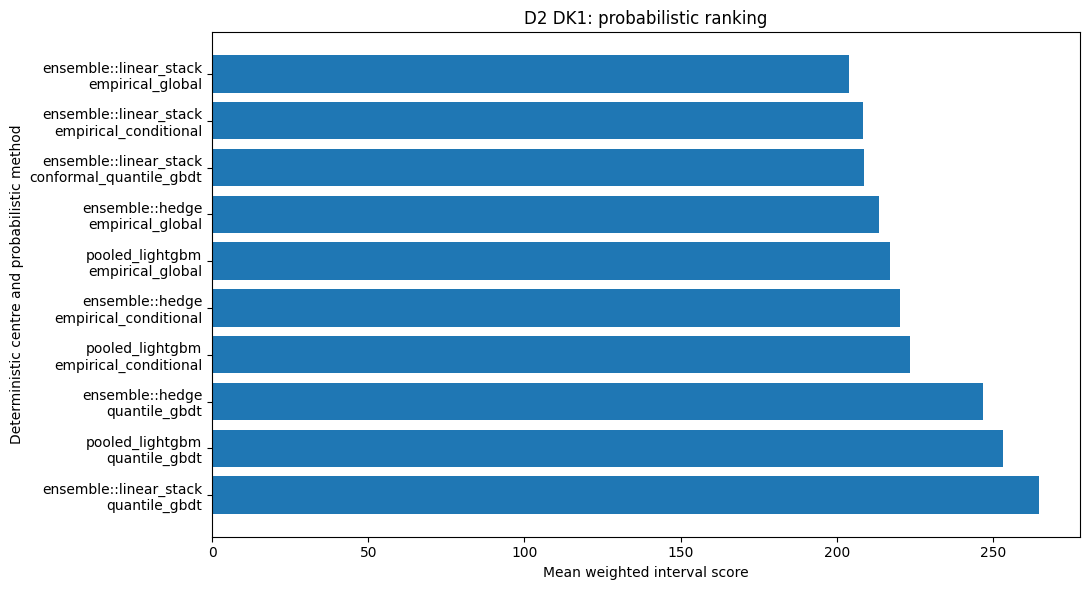

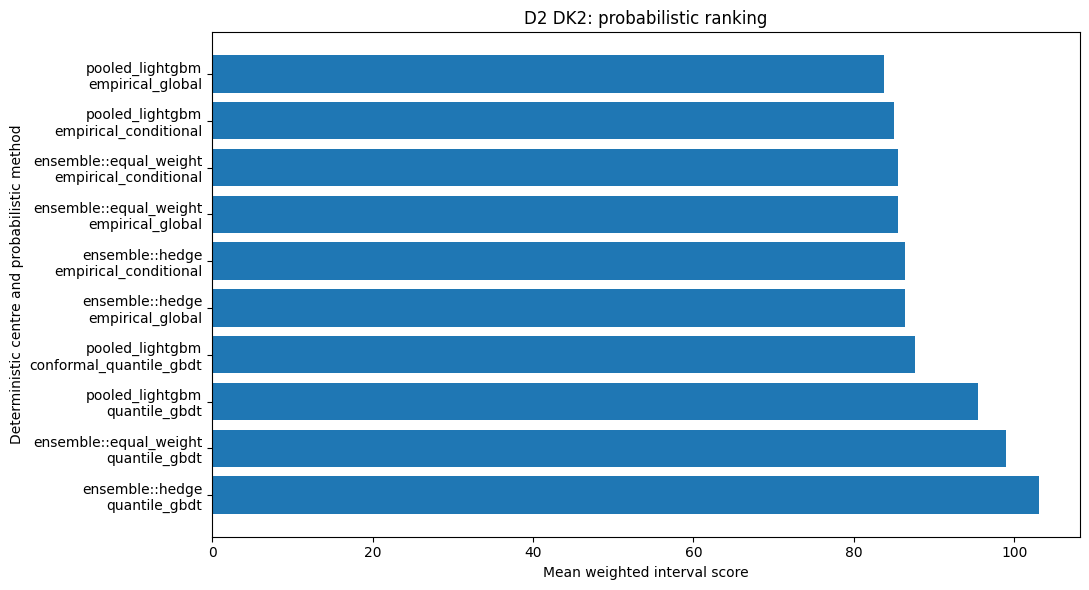

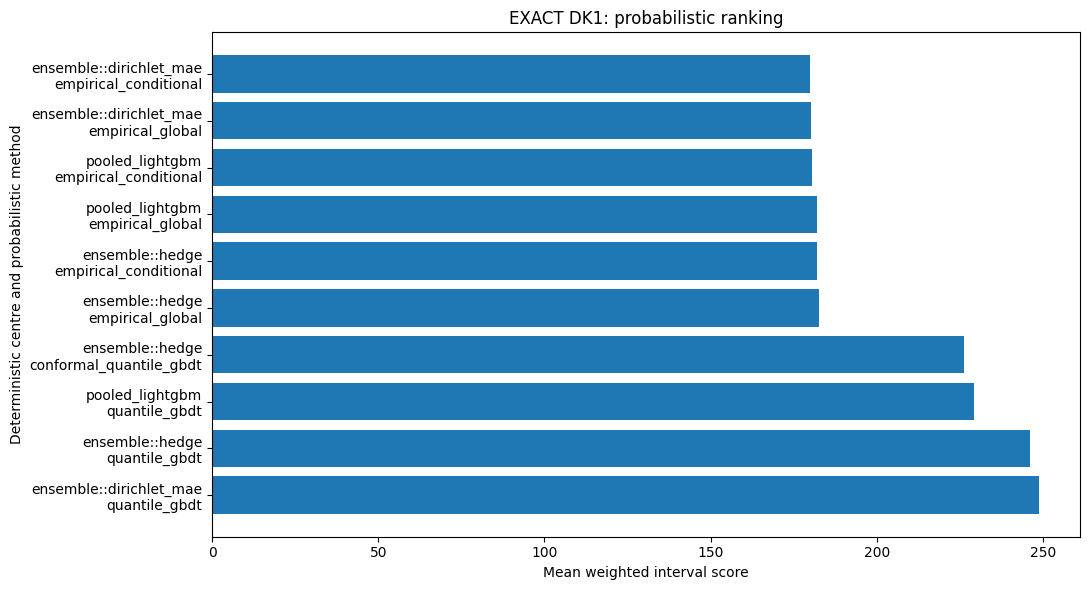

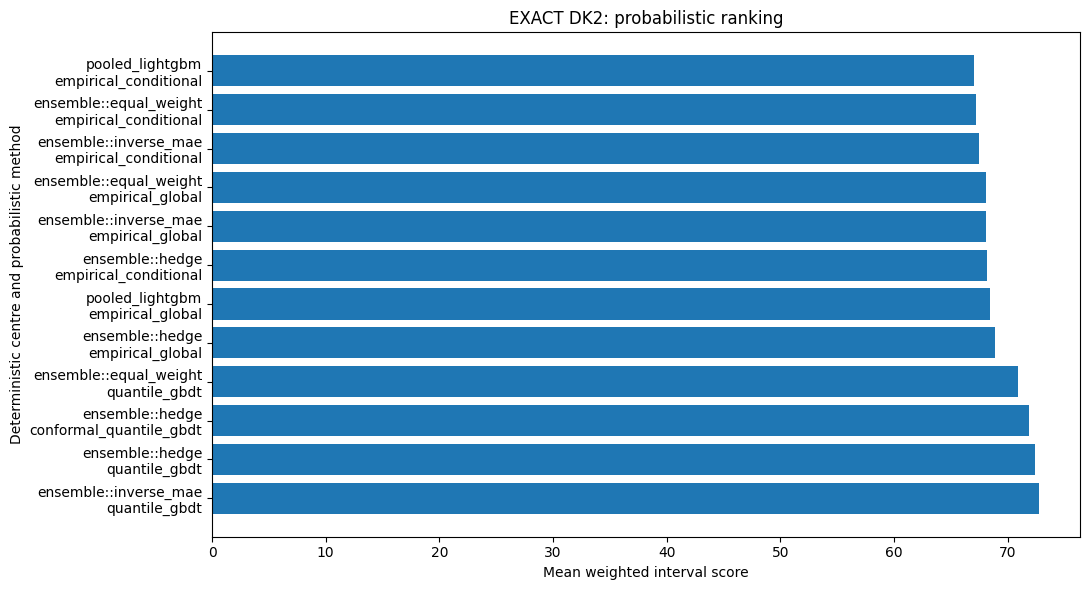

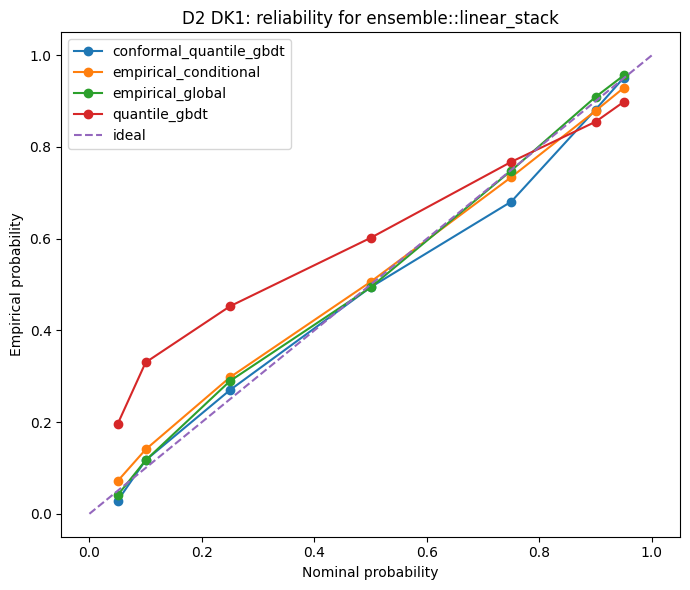

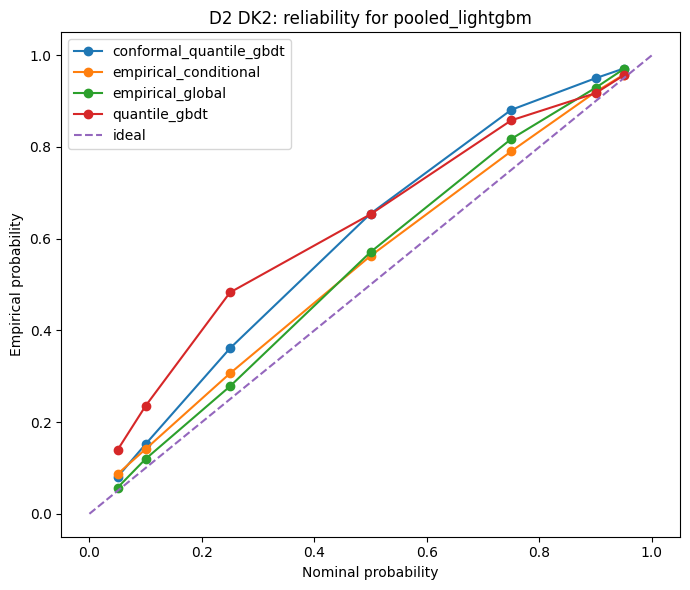

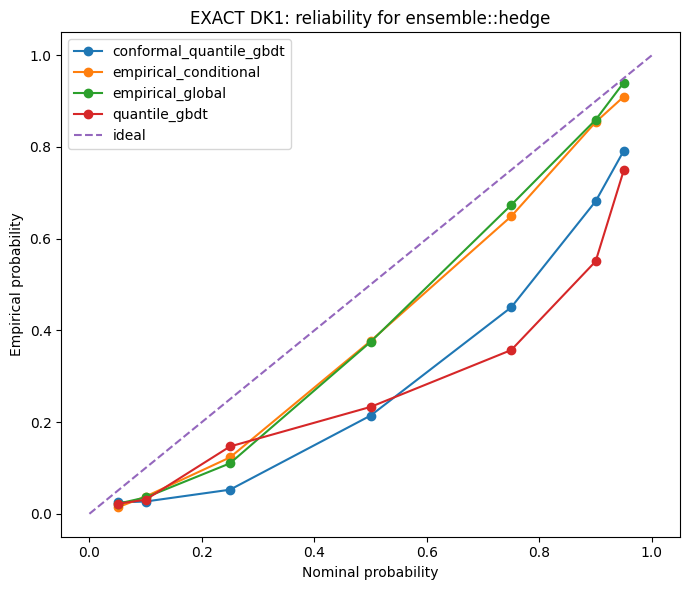

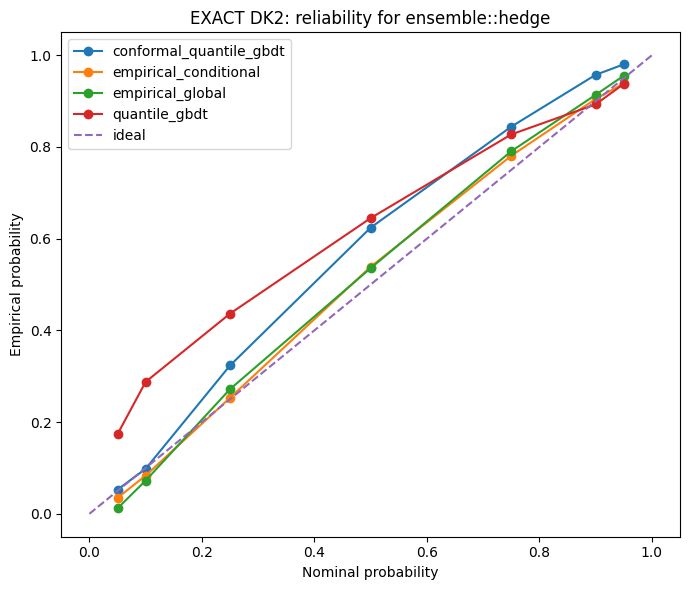

In [18]:
# ============================================================
# 17. PROBABILISTIC DIAGNOSTIC FIGURES
# ============================================================

import matplotlib.pyplot as plt


def save_current_figure(
    filename: str,
) -> None:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


for panel_name in sorted(
    probabilistic_summary["panel"].unique()
):
    for price_area in sorted(
        probabilistic_summary.loc[
            probabilistic_summary["panel"].eq(
                panel_name
            ),
            "price_area",
        ].unique()
    ):
        selected = (
            probabilistic_summary.loc[
                probabilistic_summary["panel"].eq(
                    panel_name
                )
                & probabilistic_summary[
                    "price_area"
                ].eq(price_area)
            ]
            .sort_values("mean_wis")
            .head(12)
            .copy()
        )

        labels = (
            selected["centre_model"]
            + "\n"
            + selected[
                "probabilistic_method"
            ]
        )

        plt.figure(figsize=(11, 6))
        plt.barh(
            labels[::-1],
            selected["mean_wis"][::-1],
        )
        plt.xlabel("Mean weighted interval score")
        plt.ylabel("Deterministic centre and probabilistic method")
        plt.title(
            f"{panel_name.upper()} {price_area}: "
            "probabilistic ranking"
        )

        save_current_figure(
            f"notebook_03_wis_ranking_"
            f"{panel_name}_{price_area}.png"
        )


for panel_name, price_area in PRIMARY_CENTRES:
    centre_model = PRIMARY_CENTRES[
        (panel_name, price_area)
    ]

    selected = quantile_reliability.loc[
        quantile_reliability["panel"].eq(
            panel_name
        )
        & quantile_reliability[
            "price_area"
        ].eq(price_area)
        & quantile_reliability[
            "centre_model"
        ].eq(centre_model)
    ]

    plt.figure(figsize=(7, 6))

    for method, group in selected.groupby(
        "probabilistic_method"
    ):
        ordered = group.sort_values(
            "quantile"
        )

        plt.plot(
            ordered["quantile"],
            ordered["empirical_probability"],
            marker="o",
            label=method,
        )

    plt.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        linestyle="--",
        label="ideal",
    )

    plt.xlabel("Nominal probability")
    plt.ylabel("Empirical probability")
    plt.title(
        f"{panel_name.upper()} {price_area}: "
        f"reliability for {centre_model}"
    )
    plt.legend()

    save_current_figure(
        f"notebook_03_reliability_"
        f"{panel_name}_{price_area}.png"
    )


## Joint DK1–DK2 scenario generation

Scenarios are generated only for the four primary deterministic centres.

For each evaluation local day:

1. use only residual days from earlier out-of-sample folds;
2. sample a historical residual day jointly for DK1 and DK2;
3. preserve its hourly temporal structure and cross-area dependence;
4. scale each area's residual path by the ratio of current to sampled provider
   disagreement;
5. add the scaled residual path to the deterministic centre and truncate at
   zero.

This produces coherent hourly paths rather than independent marginal draws.


In [19]:
# ============================================================
# 18. PRIMARY-CENTRE FRAME FOR SCENARIOS
# ============================================================

primary_blocks = []

for (
    panel_name,
    price_area,
), model_name in PRIMARY_CENTRES.items():
    selected = centre_predictions.loc[
        centre_predictions["panel"].eq(
            panel_name
        )
        & centre_predictions[
            "price_area"
        ].eq(price_area)
        & centre_predictions[
            "model"
        ].eq(model_name)
    ].copy()

    selected["centre_model"] = model_name
    primary_blocks.append(selected)


primary_centre_predictions = pd.concat(
    primary_blocks,
    ignore_index=True,
)

primary_centre_predictions.to_parquet(
    PREDICTION_DIR
    / "notebook_03_primary_centre_predictions.parquet",
    index=False,
)

display(
    primary_centre_predictions.groupby(
        [
            "panel",
            "price_area",
            "centre_model",
            "fold_id",
        ],
        as_index=False,
    ).size()
)


,panel,price_area,centre_model,fold_id,size
0,d2,DK1,ensemble::linear_stack,1,2161
1,d2,DK1,ensemble::linear_stack,2,2160
2,d2,DK1,ensemble::linear_stack,3,2159
3,d2,DK2,pooled_lightgbm,1,2161
4,d2,DK2,pooled_lightgbm,2,2160
5,d2,DK2,pooled_lightgbm,3,2159
6,exact,DK1,ensemble::hedge,1,1008
7,exact,DK1,ensemble::hedge,2,1008
8,exact,DK2,ensemble::hedge,1,1008
9,exact,DK2,ensemble::hedge,2,1008


In [20]:
# ============================================================
# 19. JOINT RESIDUAL-DAY LIBRARY
# ============================================================

def complete_joint_day_blocks(
    frame: pd.DataFrame,
) -> list[dict[str, Any]]:
    blocks = []

    for delivery_date, day in frame.groupby(
        "delivery_date_local"
    ):
        timestamp_counts = (
            day.groupby("timestamp_utc")[
                "price_area"
            ]
            .nunique()
        )

        complete_timestamps = (
            timestamp_counts.loc[
                timestamp_counts.eq(2)
            ]
            .index
        )

        day = day.loc[
            day["timestamp_utc"].isin(
                complete_timestamps
            )
        ].copy()

        residual_wide = day.pivot(
            index="timestamp_utc",
            columns="price_area",
            values="residual",
        ).sort_index()

        disagreement_wide = day.pivot(
            index="timestamp_utc",
            columns="price_area",
            values="expert_std",
        ).sort_index()

        hour_lookup = (
            day.drop_duplicates(
                "timestamp_utc"
            )
            .set_index("timestamp_utc")[
                "hour_local"
            ]
            .reindex(
                residual_wide.index
            )
        )

        if (
            set(residual_wide.columns)
            != {"DK1", "DK2"}
            or residual_wide.isna().any().any()
        ):
            continue

        blocks.append(
            {
                "delivery_date_local": delivery_date,
                "timestamps": residual_wide.index,
                "local_hours": tuple(
                    hour_lookup.astype(int)
                ),
                "residual_matrix": (
                    residual_wide[
                        ["DK1", "DK2"]
                    ]
                    .to_numpy(dtype=float)
                ),
                "mean_disagreement": (
                    disagreement_wide[
                        ["DK1", "DK2"]
                    ]
                    .mean()
                    .to_numpy(dtype=float)
                ),
            }
        )

    return blocks


def choose_candidate_blocks(
    library: list[dict[str, Any]],
    local_hours: tuple[int, ...],
) -> list[dict[str, Any]]:
    exact = [
        block
        for block in library
        if block["local_hours"]
        == local_hours
    ]

    if exact:
        return exact

    same_length = [
        block
        for block in library
        if len(block["local_hours"])
        == len(local_hours)
    ]

    if same_length:
        return same_length

    raise RuntimeError(
        "No historical residual day block matches "
        f"the evaluation-day length {len(local_hours)}."
    )


In [22]:
# ============================================================
# 20–21. DST-SAFE JOINT SCENARIO GENERATION
# ============================================================

from collections import defaultdict


def choose_candidate_blocks(
    library: list[dict[str, Any]],
    local_hours: tuple[int, ...],
) -> list[dict[str, Any]]:
    """
    Select historical residual-day blocks.

    Priority:
    1. Exact local-hour pattern, including DST structure.
    2. Same number of delivery hours.
    3. Standard 24-hour historical days.
    4. Any available historical day.

    Residual paths are aligned to the target local-hour sequence
    later, so a 24-hour block can safely calibrate a 23- or
    25-hour DST day.
    """
    if not library:
        raise RuntimeError(
            "The historical residual-day library is empty."
        )

    exact_pattern = [
        block
        for block in library
        if tuple(block["local_hours"])
        == tuple(local_hours)
    ]

    if exact_pattern:
        return exact_pattern

    same_length = [
        block
        for block in library
        if len(block["local_hours"])
        == len(local_hours)
    ]

    if same_length:
        return same_length

    standard_days = [
        block
        for block in library
        if len(block["local_hours"]) == 24
    ]

    if standard_days:
        return standard_days

    return library


def circular_hour_distance(
    source_hour: int,
    target_hour: int,
) -> int:
    """
    Circular distance between two clock hours.
    """
    direct = abs(
        int(source_hour)
        - int(target_hour)
    )

    return min(
        direct,
        24 - direct,
    )


def align_residual_block_to_local_hours(
    sampled_block: dict[str, Any],
    target_local_hours: tuple[int, ...],
) -> np.ndarray:
    """
    Align a sampled residual-day path to the target delivery-day
    local-hour sequence.

    DST behavior
    ------------
    23-hour spring day:
        The nonexistent local hour is omitted.

    25-hour autumn day:
        If the sampled day contains only one occurrence of the
        repeated hour, that residual is reused for the second
        occurrence.

    Missing source clock hour:
        Use the residual from the nearest available clock hour.
    """
    source_hours = tuple(
        int(hour)
        for hour in sampled_block[
            "local_hours"
        ]
    )

    source_residuals = np.asarray(
        sampled_block[
            "residual_matrix"
        ],
        dtype=float,
    )

    if source_residuals.ndim != 2:
        raise RuntimeError(
            "Sampled residual matrix must be two-dimensional."
        )

    if source_residuals.shape[1] != 2:
        raise RuntimeError(
            "Sampled residual matrix must contain DK1 and DK2."
        )

    if len(source_hours) != len(
        source_residuals
    ):
        raise RuntimeError(
            "Historical local-hour and residual lengths differ."
        )

    source_positions: dict[
        int,
        list[int],
    ] = defaultdict(list)

    for source_position, source_hour in enumerate(
        source_hours
    ):
        source_positions[
            source_hour
        ].append(source_position)

    target_occurrences: dict[
        int,
        int,
    ] = defaultdict(int)

    aligned_rows = []

    for target_hour_raw in target_local_hours:
        target_hour = int(
            target_hour_raw
        )

        occurrence_number = (
            target_occurrences[
                target_hour
            ]
        )

        target_occurrences[
            target_hour
        ] += 1

        matching_positions = (
            source_positions.get(
                target_hour,
                [],
            )
        )

        if matching_positions:
            # Exact clock-hour match. For a repeated target hour
            # use the corresponding source occurrence when it
            # exists; otherwise reuse the last occurrence.
            selected_position = (
                matching_positions[
                    min(
                        occurrence_number,
                        len(
                            matching_positions
                        )
                        - 1,
                    )
                ]
            )
        else:
            # Rare fallback: the sampled DST day does not contain
            # a clock hour required by the target day.
            selected_position = min(
                range(len(source_hours)),
                key=lambda position: (
                    circular_hour_distance(
                        source_hours[
                            position
                        ],
                        target_hour,
                    ),
                    position,
                ),
            )

        aligned_rows.append(
            source_residuals[
                selected_position
            ]
        )

    aligned_matrix = np.vstack(
        aligned_rows
    )

    if len(aligned_matrix) != len(
        target_local_hours
    ):
        raise RuntimeError(
            "DST residual alignment produced the wrong "
            "number of delivery hours."
        )

    return aligned_matrix


def generate_panel_fold_scenarios(
    frame: pd.DataFrame,
    *,
    panel_name: str,
    evaluation_fold: int,
) -> pd.DataFrame:
    history = frame.loc[
        frame["panel"].eq(
            panel_name
        )
        & (
            frame["fold_id"]
            < evaluation_fold
        )
    ].copy()

    evaluation = frame.loc[
        frame["panel"].eq(
            panel_name
        )
        & frame["fold_id"].eq(
            evaluation_fold
        )
    ].copy()

    if history.empty:
        raise RuntimeError(
            "No historical residual rows for "
            f"{panel_name} fold {evaluation_fold}."
        )

    if evaluation.empty:
        raise RuntimeError(
            "No evaluation rows for "
            f"{panel_name} fold {evaluation_fold}."
        )

    library = complete_joint_day_blocks(
        history
    )

    if not library:
        raise RuntimeError(
            "No complete joint DK1–DK2 residual-day "
            f"blocks for {panel_name} fold "
            f"{evaluation_fold}."
        )

    rng = np.random.default_rng(
        stable_seed(
            RANDOM_SEED,
            panel_name,
            evaluation_fold,
            "joint_scenarios",
        )
    )

    generated_blocks = []

    for (
        delivery_date,
        day,
    ) in evaluation.groupby(
        "delivery_date_local"
    ):
        day = day.sort_values(
            [
                "timestamp_utc",
                "price_area",
            ]
        )

        centre_wide = (
            day.pivot(
                index="timestamp_utc",
                columns="price_area",
                values="prediction",
            )
            .sort_index()
        )

        actual_wide = (
            day.pivot(
                index="timestamp_utc",
                columns="price_area",
                values=TARGET_COLUMN,
            )
            .sort_index()
        )

        disagreement_wide = (
            day.pivot(
                index="timestamp_utc",
                columns="price_area",
                values="expert_std",
            )
            .sort_index()
        )

        model_wide = (
            day.pivot(
                index="timestamp_utc",
                columns="price_area",
                values="centre_model",
            )
            .sort_index()
        )

        hour_lookup = (
            day.drop_duplicates(
                "timestamp_utc"
            )
            .set_index(
                "timestamp_utc"
            )["hour_local"]
            .reindex(
                centre_wide.index
            )
        )

        required_areas = {
            "DK1",
            "DK2",
        }

        if set(
            centre_wide.columns
        ) != required_areas:
            raise RuntimeError(
                "Primary-centre evaluation day is missing "
                f"an area: {panel_name}, {delivery_date}."
            )

        if centre_wide.isna().any().any():
            raise RuntimeError(
                "Primary-centre predictions are incomplete: "
                f"{panel_name}, {delivery_date}."
            )

        if actual_wide.isna().any().any():
            raise RuntimeError(
                "Actual wind observations are incomplete: "
                f"{panel_name}, {delivery_date}."
            )

        if hour_lookup.isna().any():
            raise RuntimeError(
                "Local-hour labels are incomplete: "
                f"{panel_name}, {delivery_date}."
            )

        local_hours = tuple(
            hour_lookup.astype(int)
        )

        candidates = choose_candidate_blocks(
            library,
            local_hours,
        )

        current_disagreement = (
            disagreement_wide[
                ["DK1", "DK2"]
            ]
            .mean()
            .to_numpy(dtype=float)
        )

        current_disagreement = np.where(
            np.isfinite(
                current_disagreement
            ),
            current_disagreement,
            1.0,
        )

        current_disagreement = np.maximum(
            current_disagreement,
            1e-6,
        )

        centre_matrix = (
            centre_wide[
                ["DK1", "DK2"]
            ]
            .to_numpy(dtype=float)
        )

        actual_matrix = (
            actual_wide[
                ["DK1", "DK2"]
            ]
            .to_numpy(dtype=float)
        )

        for scenario_id in range(
            1,
            SCENARIO_COUNT + 1,
        ):
            sampled_block = candidates[
                int(
                    rng.integers(
                        0,
                        len(candidates),
                    )
                )
            ]

            sampled_residual = (
                align_residual_block_to_local_hours(
                    sampled_block,
                    local_hours,
                )
            )

            sampled_disagreement = np.asarray(
                sampled_block[
                    "mean_disagreement"
                ],
                dtype=float,
            )

            sampled_disagreement = np.where(
                np.isfinite(
                    sampled_disagreement
                ),
                sampled_disagreement,
                1.0,
            )

            sampled_disagreement = np.maximum(
                sampled_disagreement,
                1e-6,
            )

            disagreement_scale = np.clip(
                current_disagreement
                / sampled_disagreement,
                SCENARIO_SCALE_LOWER,
                SCENARIO_SCALE_UPPER,
            )

            scenario_matrix = np.maximum(
                centre_matrix
                + sampled_residual
                * disagreement_scale[
                    None,
                    :
                ],
                0.0,
            )

            if scenario_matrix.shape != (
                len(centre_wide),
                2,
            ):
                raise RuntimeError(
                    "Scenario matrix has the wrong shape for "
                    f"{panel_name}, {delivery_date}."
                )

            for (
                area_index,
                price_area,
            ) in enumerate(
                ("DK1", "DK2")
            ):
                generated_blocks.append(
                    pd.DataFrame(
                        {
                            "panel": panel_name,
                            "fold_id": (
                                evaluation_fold
                            ),
                            "delivery_date_local": (
                                delivery_date
                            ),
                            "timestamp_utc": (
                                centre_wide.index
                            ),
                            "price_area": (
                                price_area
                            ),
                            "scenario_id": (
                                scenario_id
                            ),
                            "centre_model": (
                                model_wide[
                                    price_area
                                ].to_numpy()
                            ),
                            "centre_prediction": (
                                centre_matrix[
                                    :,
                                    area_index,
                                ]
                            ),
                            TARGET_COLUMN: (
                                actual_matrix[
                                    :,
                                    area_index,
                                ]
                            ),
                            "scenario_wind_mwh": (
                                scenario_matrix[
                                    :,
                                    area_index,
                                ]
                            ),
                            "sampled_residual_date_local": (
                                sampled_block[
                                    "delivery_date_local"
                                ]
                            ),
                            "sampled_day_hours": len(
                                sampled_block[
                                    "local_hours"
                                ]
                            ),
                            "target_day_hours": len(
                                local_hours
                            ),
                            "dst_alignment_applied": (
                                tuple(
                                    sampled_block[
                                        "local_hours"
                                    ]
                                )
                                != tuple(
                                    local_hours
                                )
                            ),
                            "disagreement_scale": (
                                disagreement_scale[
                                    area_index
                                ]
                            ),
                        }
                    )
                )

    if not generated_blocks:
        raise RuntimeError(
            "No scenarios were generated for "
            f"{panel_name} fold {evaluation_fold}."
        )

    return pd.concat(
        generated_blocks,
        ignore_index=True,
    )


# ------------------------------------------------------------
# Generate all scenario folds
# ------------------------------------------------------------

scenario_blocks = []

if RUN_SCENARIOS:
    for panel_name in (
        "d2",
        "exact",
    ):
        panel_folds = sorted(
            primary_centre_predictions.loc[
                primary_centre_predictions[
                    "panel"
                ].eq(panel_name),
                "fold_id",
            ].unique()
        )

        for evaluation_fold in panel_folds[
            1:
        ]:
            scenario_blocks.append(
                generate_panel_fold_scenarios(
                    primary_centre_predictions,
                    panel_name=panel_name,
                    evaluation_fold=int(
                        evaluation_fold
                    ),
                )
            )


joint_scenarios = (
    pd.concat(
        scenario_blocks,
        ignore_index=True,
    )
    if scenario_blocks
    else pd.DataFrame()
)

if not joint_scenarios.empty:
    joint_scenarios.to_parquet(
        SCENARIO_DIR
        / "notebook_03_joint_wind_scenarios.parquet",
        index=False,
    )


# ------------------------------------------------------------
# DST alignment audit
# ------------------------------------------------------------

scenario_dst_audit = (
    joint_scenarios[
        [
            "panel",
            "fold_id",
            "delivery_date_local",
            "sampled_residual_date_local",
            "sampled_day_hours",
            "target_day_hours",
            "dst_alignment_applied",
        ]
    ]
    .drop_duplicates()
    .groupby(
        [
            "panel",
            "fold_id",
            "target_day_hours",
        ],
        as_index=False,
    )
    .agg(
        sampled_days=(
            "sampled_residual_date_local",
            "nunique",
        ),
        generated_delivery_days=(
            "delivery_date_local",
            "nunique",
        ),
        dst_alignment_share=(
            "dst_alignment_applied",
            "mean",
        ),
    )
)

scenario_dst_audit.to_csv(
    TABLE_DIR
    / "notebook_03_scenario_dst_alignment_audit.csv",
    index=False,
)

print(
    {
        "joint_scenario_rows": int(
            len(joint_scenarios)
        ),
        "scenario_count": (
            SCENARIO_COUNT
        ),
        "target_day_lengths": sorted(
            joint_scenarios[
                "target_day_hours"
            ].unique()
        ),
    }
)

display(scenario_dst_audit)

{'joint_scenario_rows': 2663500, 'scenario_count': 250, 'target_day_lengths': [np.int64(23), np.int64(24)]}


,panel,fold_id,target_day_hours,sampled_days,generated_delivery_days,dst_alignment_share
0,d2,2,24,89,90,0.0
1,d2,3,23,133,1,1.0
2,d2,3,24,179,89,0.0
3,exact,2,24,42,42,0.0


In [23]:
# ============================================================
# 21. MARGINAL SCENARIO EVALUATION
# ============================================================

def ensemble_crps(
    ensemble: np.ndarray,
    actual: float,
) -> float:
    values = np.sort(
        np.asarray(
            ensemble,
            dtype=float,
        )
    )

    n = len(values)

    if n == 0:
        return np.nan

    first_term = float(
        np.mean(
            np.abs(values - actual)
        )
    )

    ranks = np.arange(
        1,
        n + 1,
        dtype=float,
    )

    pair_term = float(
        np.sum(
            (
                2.0 * ranks
                - n
                - 1.0
            )
            * values
        )
        / (n ** 2)
    )

    return first_term - pair_term


scenario_marginal_rows = []

if not joint_scenarios.empty:
    for keys, group in joint_scenarios.groupby(
        [
            "panel",
            "fold_id",
            "timestamp_utc",
            "price_area",
            "centre_model",
        ]
    ):
        (
            panel_name,
            fold_id,
            timestamp_utc,
            price_area,
            centre_model,
        ) = keys

        values = group[
            "scenario_wind_mwh"
        ].to_numpy(dtype=float)

        actual = float(
            group[TARGET_COLUMN].iloc[0]
        )

        q05, q10, q50, q90, q95 = (
            np.quantile(
                values,
                [
                    0.05,
                    0.10,
                    0.50,
                    0.90,
                    0.95,
                ],
            )
        )

        scenario_marginal_rows.append(
            {
                "panel": panel_name,
                "fold_id": fold_id,
                "timestamp_utc": timestamp_utc,
                "price_area": price_area,
                "centre_model": centre_model,
                TARGET_COLUMN: actual,
                "scenario_crps": ensemble_crps(
                    values,
                    actual,
                ),
                "coverage_80": float(
                    q10 <= actual <= q90
                ),
                "width_80": q90 - q10,
                "coverage_90": float(
                    q05 <= actual <= q95
                ),
                "width_90": q95 - q05,
                "scenario_median_mae": abs(
                    q50 - actual
                ),
                "scenario_median_bias": (
                    q50 - actual
                ),
            }
        )


scenario_marginal_metrics = pd.DataFrame(
    scenario_marginal_rows
)

scenario_marginal_summary = (
    scenario_marginal_metrics.groupby(
        [
            "panel",
            "fold_id",
            "price_area",
            "centre_model",
        ],
        as_index=False,
    )
    .agg(
        mean_scenario_crps=(
            "scenario_crps",
            "mean",
        ),
        coverage_80=(
            "coverage_80",
            "mean",
        ),
        width_80=("width_80", "mean"),
        coverage_90=(
            "coverage_90",
            "mean",
        ),
        width_90=("width_90", "mean"),
        scenario_median_mae=(
            "scenario_median_mae",
            "mean",
        ),
        scenario_median_bias=(
            "scenario_median_bias",
            "mean",
        ),
        observations=(
            "timestamp_utc",
            "size",
        ),
    )
    if not scenario_marginal_metrics.empty
    else pd.DataFrame()
)

scenario_marginal_metrics.to_parquet(
    SCENARIO_DIR
    / "notebook_03_scenario_marginal_metrics.parquet",
    index=False,
)

scenario_marginal_summary.to_csv(
    TABLE_DIR
    / "notebook_03_scenario_marginal_summary.csv",
    index=False,
)

display(scenario_marginal_summary)


,panel,fold_id,price_area,centre_model,mean_scenario_crps,coverage_80,width_80,coverage_90,width_90,scenario_median_mae,scenario_median_bias,observations
0,d2,2,DK1,ensemble::linear_stack,259.544118,0.733333,1101.312007,0.895833,1564.392218,368.034393,20.764110,2160
1,d2,2,DK2,pooled_lightgbm,99.318406,0.843981,501.223411,0.926389,683.084468,135.014063,23.663756,2160
2,d2,3,DK1,ensemble::linear_stack,248.653236,0.773969,938.377952,0.869847,1212.993680,338.749899,9.441810,2159
3,d2,3,DK2,pooled_lightgbm,101.597665,0.761000,362.268080,0.859194,490.424262,136.185969,14.836708,2159
4,exact,2,DK1,ensemble::hedge,216.263376,0.753968,747.068519,0.849206,1073.618307,291.329925,-123.508138,1008
5,exact,2,DK2,ensemble::hedge,81.207377,0.833333,356.970131,0.924603,488.115130,112.686154,5.059254,1008


In [24]:
# ============================================================
# 22. DAILY JOINT ENERGY SCORE AND TOTAL-WIND COVERAGE
# ============================================================

def approximate_energy_score(
    scenario_matrix: np.ndarray,
    actual_vector: np.ndarray,
    *,
    pair_draws: int,
    seed: int,
) -> float:
    scenarios = np.asarray(
        scenario_matrix,
        dtype=float,
    )

    actual = np.asarray(
        actual_vector,
        dtype=float,
    )

    first_term = float(
        np.mean(
            np.linalg.norm(
                scenarios
                - actual[None, :],
                axis=1,
            )
        )
    )

    rng = np.random.default_rng(seed)

    first_indices = rng.integers(
        0,
        len(scenarios),
        size=pair_draws,
    )

    second_indices = rng.integers(
        0,
        len(scenarios),
        size=pair_draws,
    )

    second_term = float(
        np.mean(
            np.linalg.norm(
                scenarios[first_indices]
                - scenarios[second_indices],
                axis=1,
            )
        )
    )

    return (
        first_term
        - 0.5 * second_term
    )


daily_joint_rows = []
daily_total_rows = []

if not joint_scenarios.empty:
    for keys, day in joint_scenarios.groupby(
        [
            "panel",
            "fold_id",
            "delivery_date_local",
        ]
    ):
        (
            panel_name,
            fold_id,
            delivery_date,
        ) = keys

        actual_wide = (
            day.drop_duplicates(
                [
                    "timestamp_utc",
                    "price_area",
                ]
            )
            .pivot(
                index="timestamp_utc",
                columns="price_area",
                values=TARGET_COLUMN,
            )
            .sort_index()
        )

        scenario_cube = []

        for scenario_id, scenario in day.groupby(
            "scenario_id"
        ):
            scenario_wide = (
                scenario.pivot(
                    index="timestamp_utc",
                    columns="price_area",
                    values="scenario_wind_mwh",
                )
                .reindex(
                    actual_wide.index
                )
            )

            scenario_cube.append(
                scenario_wide[
                    ["DK1", "DK2"]
                ]
                .to_numpy(dtype=float)
                .reshape(-1)
            )

        scenario_matrix = np.vstack(
            scenario_cube
        )

        actual_vector = (
            actual_wide[
                ["DK1", "DK2"]
            ]
            .to_numpy(dtype=float)
            .reshape(-1)
        )

        daily_joint_rows.append(
            {
                "panel": panel_name,
                "fold_id": fold_id,
                "delivery_date_local": delivery_date,
                "joint_energy_score": (
                    approximate_energy_score(
                        scenario_matrix,
                        actual_vector,
                        pair_draws=(
                            ENERGY_SCORE_PAIR_DRAWS
                        ),
                        seed=stable_seed(
                            RANDOM_SEED,
                            panel_name,
                            fold_id,
                            delivery_date,
                            "energy_score",
                        ),
                    )
                ),
                "hours": len(actual_wide),
                "scenario_count": len(
                    scenario_matrix
                ),
            }
        )

        for price_area in (
            "DK1",
            "DK2",
        ):
            area_day = day.loc[
                day["price_area"].eq(
                    price_area
                )
            ]

            actual_total = float(
                area_day.drop_duplicates(
                    "timestamp_utc"
                )[TARGET_COLUMN].sum()
            )

            scenario_totals = (
                area_day.groupby(
                    "scenario_id"
                )["scenario_wind_mwh"]
                .sum()
                .to_numpy(dtype=float)
            )

            q05, q10, q50, q90, q95 = (
                np.quantile(
                    scenario_totals,
                    [
                        0.05,
                        0.10,
                        0.50,
                        0.90,
                        0.95,
                    ],
                )
            )

            daily_total_rows.append(
                {
                    "panel": panel_name,
                    "fold_id": fold_id,
                    "delivery_date_local": delivery_date,
                    "price_area": price_area,
                    "actual_daily_total_mwh": actual_total,
                    "scenario_daily_total_median_mwh": q50,
                    "daily_total_crps": ensemble_crps(
                        scenario_totals,
                        actual_total,
                    ),
                    "daily_total_coverage_80": float(
                        q10
                        <= actual_total
                        <= q90
                    ),
                    "daily_total_width_80": (
                        q90 - q10
                    ),
                    "daily_total_coverage_90": float(
                        q05
                        <= actual_total
                        <= q95
                    ),
                    "daily_total_width_90": (
                        q95 - q05
                    ),
                }
            )


daily_joint_metrics = pd.DataFrame(
    daily_joint_rows
)

daily_total_metrics = pd.DataFrame(
    daily_total_rows
)

daily_joint_summary = (
    daily_joint_metrics.groupby(
        ["panel", "fold_id"],
        as_index=False,
    )
    .agg(
        mean_joint_energy_score=(
            "joint_energy_score",
            "mean",
        ),
        days=(
            "delivery_date_local",
            "nunique",
        ),
    )
    if not daily_joint_metrics.empty
    else pd.DataFrame()
)

daily_total_summary = (
    daily_total_metrics.groupby(
        [
            "panel",
            "fold_id",
            "price_area",
        ],
        as_index=False,
    )
    .agg(
        mean_daily_total_crps=(
            "daily_total_crps",
            "mean",
        ),
        daily_total_coverage_80=(
            "daily_total_coverage_80",
            "mean",
        ),
        daily_total_width_80=(
            "daily_total_width_80",
            "mean",
        ),
        daily_total_coverage_90=(
            "daily_total_coverage_90",
            "mean",
        ),
        daily_total_width_90=(
            "daily_total_width_90",
            "mean",
        ),
        days=(
            "delivery_date_local",
            "nunique",
        ),
    )
    if not daily_total_metrics.empty
    else pd.DataFrame()
)

daily_joint_metrics.to_csv(
    TABLE_DIR
    / "notebook_03_daily_joint_energy_scores.csv",
    index=False,
)

daily_total_metrics.to_csv(
    TABLE_DIR
    / "notebook_03_daily_total_scenario_metrics.csv",
    index=False,
)

daily_joint_summary.to_csv(
    TABLE_DIR
    / "notebook_03_daily_joint_energy_score_summary.csv",
    index=False,
)

daily_total_summary.to_csv(
    TABLE_DIR
    / "notebook_03_daily_total_scenario_summary.csv",
    index=False,
)

display(daily_joint_summary)
display(daily_total_summary)


,panel,fold_id,mean_joint_energy_score,days
0,d2,2,1609.409548,90
1,d2,3,1616.427188,90
2,exact,2,1390.065239,42


,panel,fold_id,price_area,mean_daily_total_crps,daily_total_coverage_80,daily_total_width_80,daily_total_coverage_90,daily_total_width_90,days
0,d2,2,DK1,4690.800008,0.633333,17073.482697,0.822222,26106.230814,90
1,d2,2,DK2,1555.300677,0.777778,7550.185121,0.888889,10446.695648,90
2,d2,3,DK1,4082.585081,0.744444,16030.041064,0.844444,21678.899714,90
3,d2,3,DK2,1571.339417,0.722222,5607.122874,0.844444,7918.487293,90
4,exact,2,DK1,3559.332893,0.690476,10771.509974,0.833333,16613.376004,42
5,exact,2,DK2,1283.217371,0.761905,5101.164117,0.952381,7345.781882,42


In [25]:
# ============================================================
# 23. SCENARIO DEPENDENCE DIAGNOSTICS
# ============================================================

dependence_rows = []

if not joint_scenarios.empty:
    for keys, group in joint_scenarios.groupby(
        ["panel", "fold_id"]
    ):
        panel_name, fold_id = keys

        actual_residual = (
            primary_centre_predictions.loc[
                primary_centre_predictions[
                    "panel"
                ].eq(panel_name)
                & primary_centre_predictions[
                    "fold_id"
                ].eq(fold_id)
            ]
            .pivot(
                index="timestamp_utc",
                columns="price_area",
                values="residual",
            )
            .dropna()
        )

        actual_correlation = float(
            actual_residual["DK1"].corr(
                actual_residual["DK2"]
            )
        )

        scenario_correlations = []

        for scenario_id, scenario in group.groupby(
            "scenario_id"
        ):
            residual_wide = (
                scenario.assign(
                    scenario_residual=lambda frame: (
                        frame["scenario_wind_mwh"]
                        - frame["centre_prediction"]
                    )
                )
                .pivot(
                    index="timestamp_utc",
                    columns="price_area",
                    values="scenario_residual",
                )
                .dropna()
            )

            if len(residual_wide) >= 2:
                scenario_correlations.append(
                    float(
                        residual_wide[
                            "DK1"
                        ].corr(
                            residual_wide[
                                "DK2"
                            ]
                        )
                    )
                )

        dependence_rows.append(
            {
                "panel": panel_name,
                "fold_id": fold_id,
                "actual_residual_correlation": actual_correlation,
                "mean_scenario_residual_correlation": float(
                    np.nanmean(
                        scenario_correlations
                    )
                ),
                "std_scenario_residual_correlation": float(
                    np.nanstd(
                        scenario_correlations
                    )
                ),
                "scenario_count": len(
                    scenario_correlations
                ),
            }
        )


scenario_dependence = pd.DataFrame(
    dependence_rows
)

scenario_dependence.to_csv(
    TABLE_DIR
    / "notebook_03_scenario_dependence_diagnostics.csv",
    index=False,
)

display(scenario_dependence)


,panel,fold_id,actual_residual_correlation,mean_scenario_residual_correlation,std_scenario_residual_correlation,scenario_count
0,d2,2,0.258725,0.377525,0.069307,250
1,d2,3,0.370737,0.297015,0.065496,250
2,exact,2,0.437418,0.329126,0.107196,250


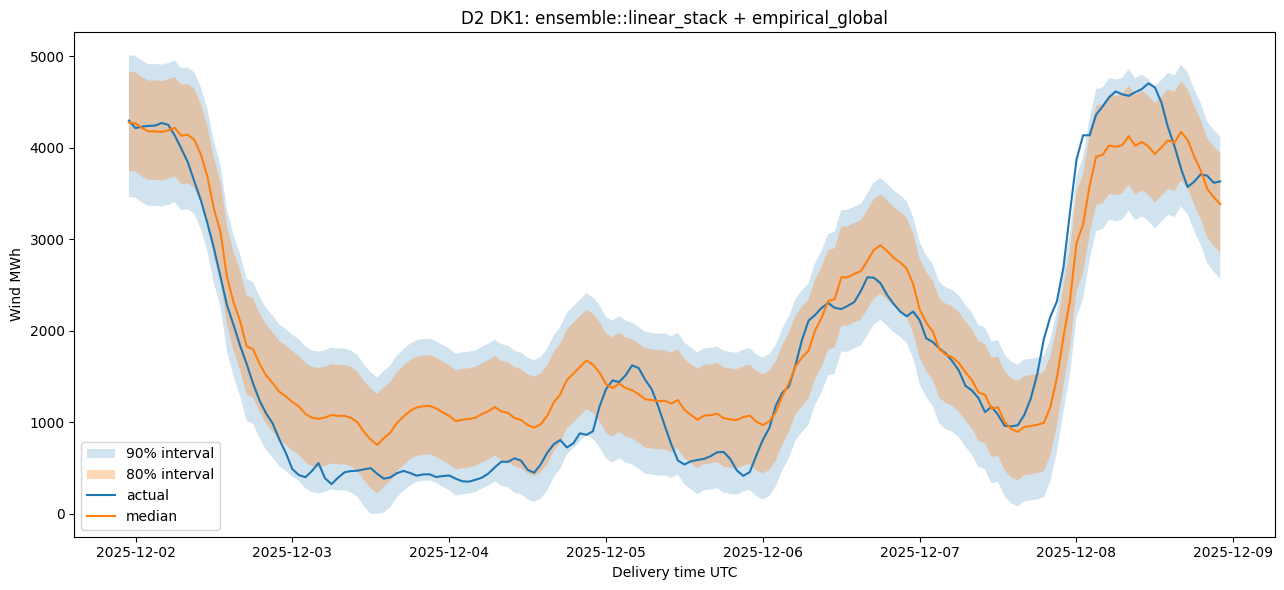

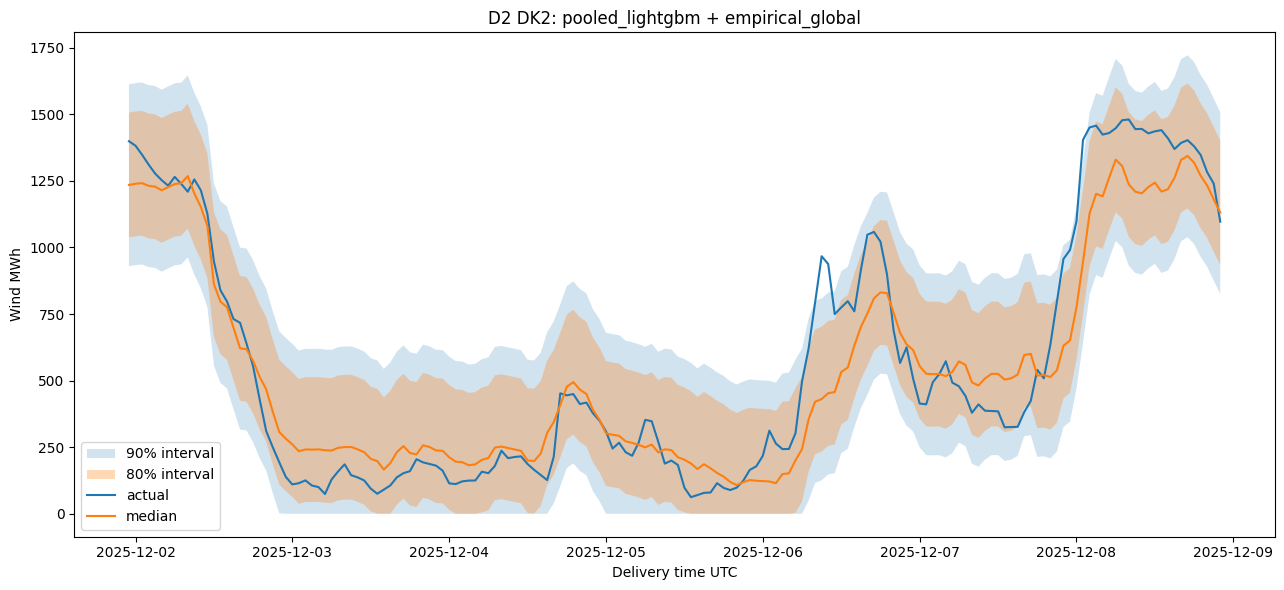

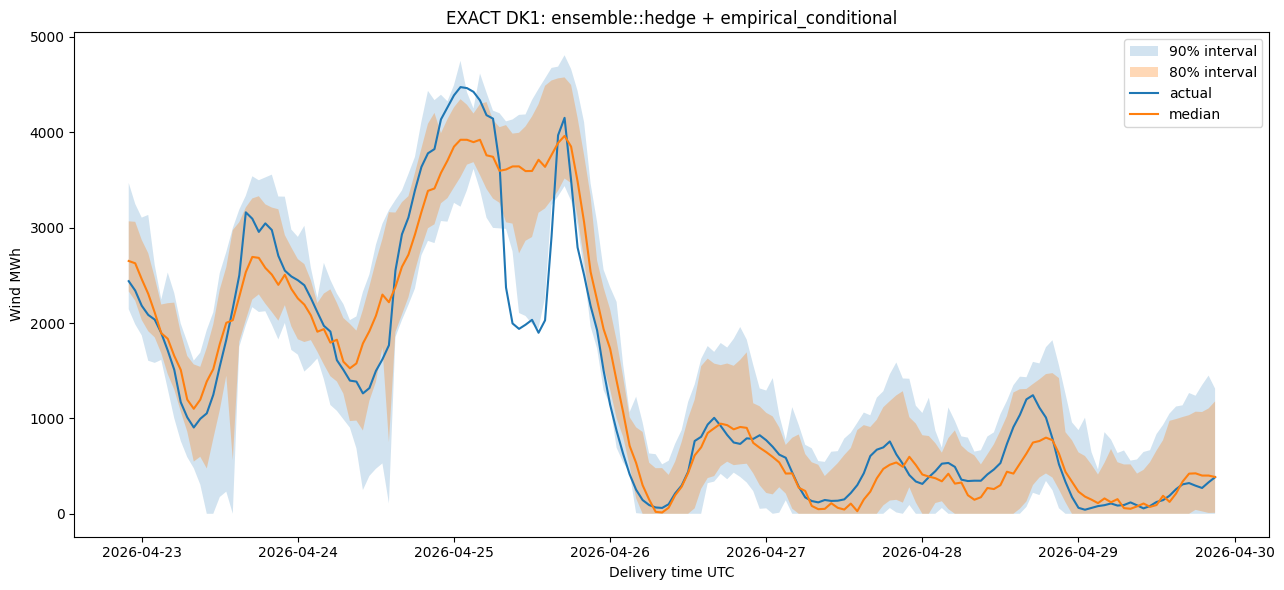

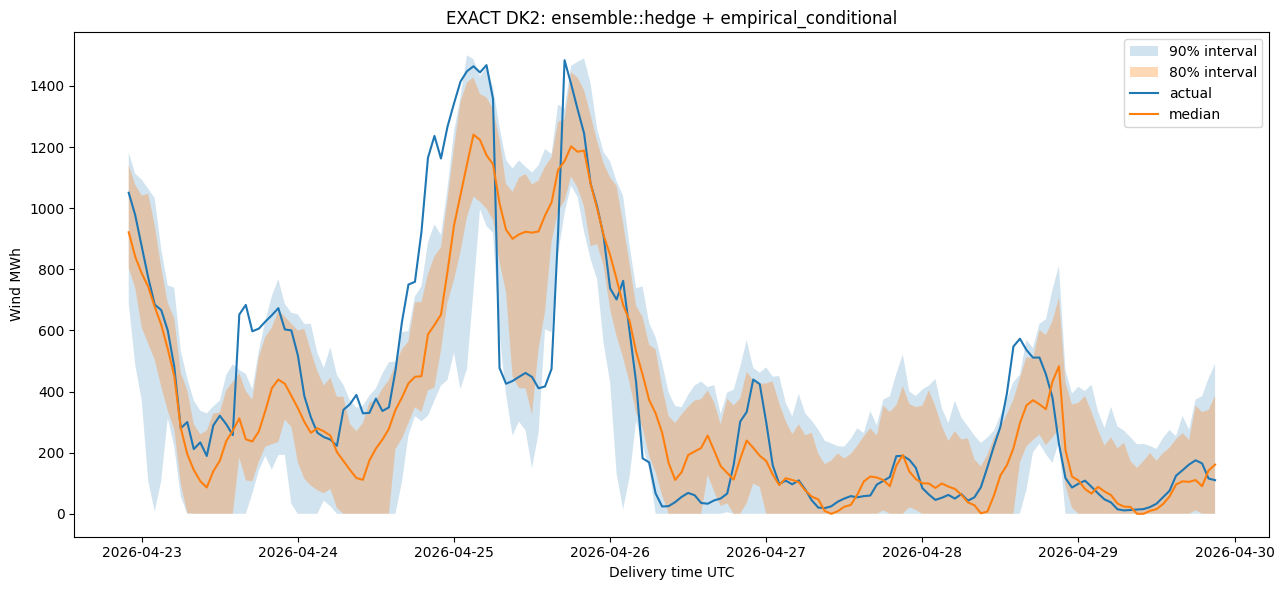

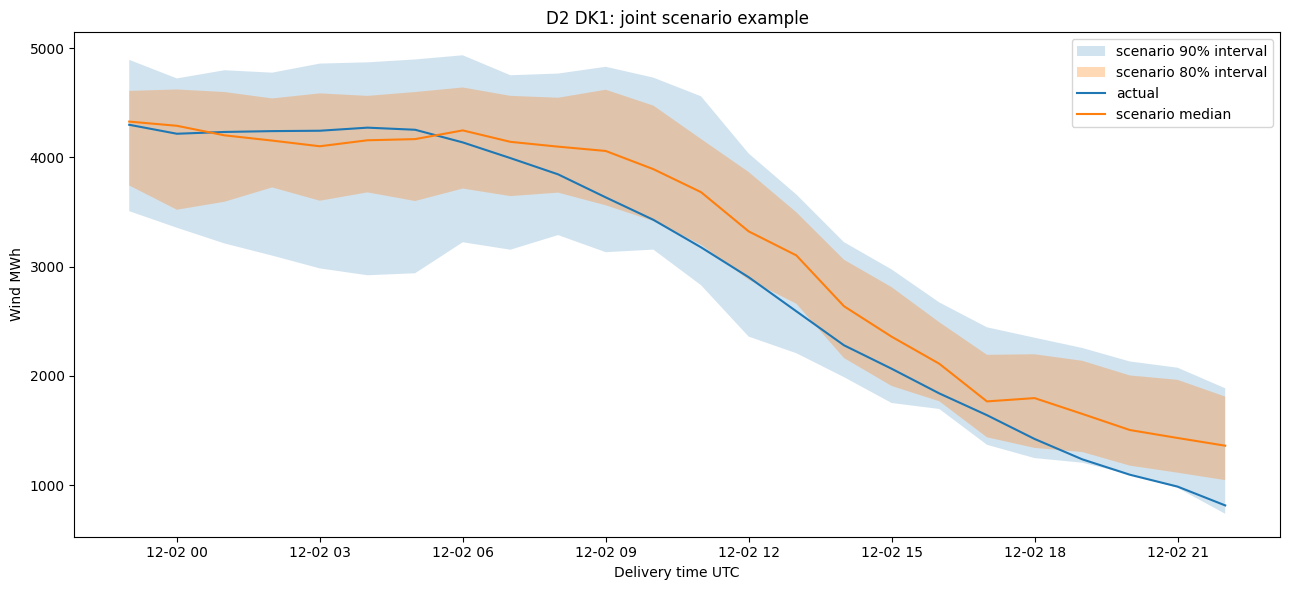

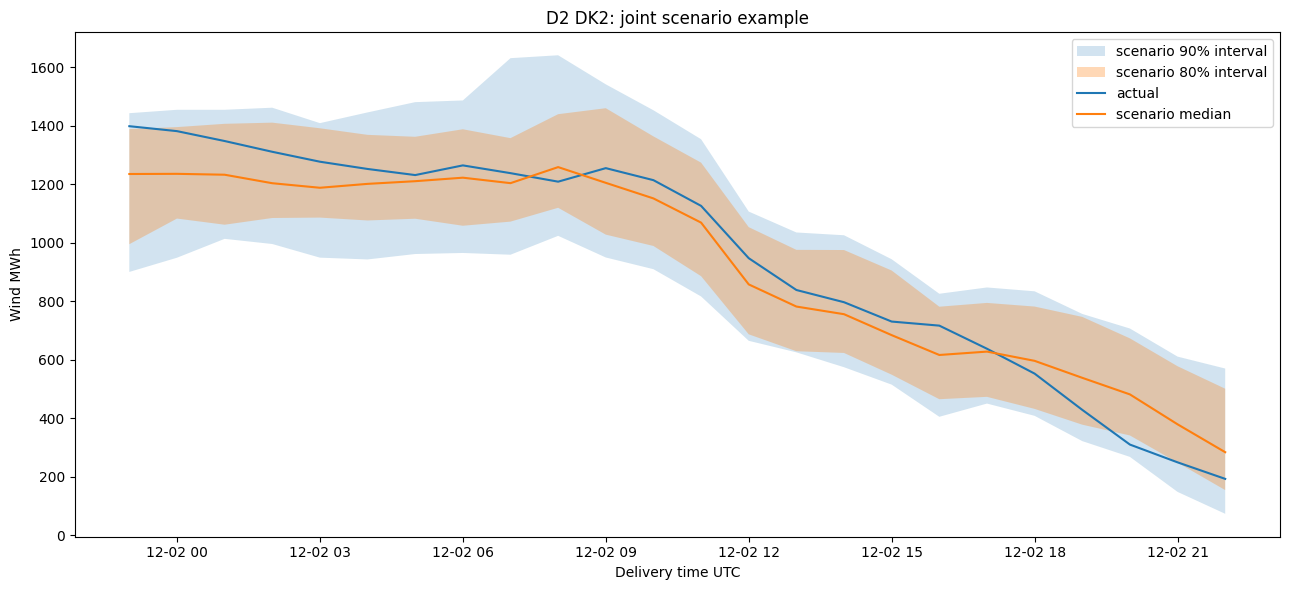

In [26]:
# ============================================================
# 24. EXAMPLE INTERVAL AND SCENARIO FIGURES
# ============================================================

for (
    panel_name,
    price_area,
), centre_model in PRIMARY_CENTRES.items():
    available_methods = (
        probabilistic_summary.loc[
            probabilistic_summary["panel"].eq(
                panel_name
            )
            & probabilistic_summary[
                "price_area"
            ].eq(price_area)
            & probabilistic_summary[
                "centre_model"
            ].eq(centre_model)
        ]
        .sort_values("mean_wis")
    )

    if available_methods.empty:
        continue

    best_method = str(
        available_methods.iloc[0][
            "probabilistic_method"
        ]
    )

    selected = quantile_wide.loc[
        quantile_wide["panel"].eq(
            panel_name
        )
        & quantile_wide[
            "price_area"
        ].eq(price_area)
        & quantile_wide[
            "centre_model"
        ].eq(centre_model)
        & quantile_wide[
            "probabilistic_method"
        ].eq(best_method)
    ].sort_values("timestamp_utc")

    if selected.empty:
        continue

    example = selected.head(
        7 * 24
    )

    plt.figure(figsize=(13, 6))
    plt.fill_between(
        example["timestamp_utc"],
        example[quantile_column(0.05)],
        example[quantile_column(0.95)],
        alpha=0.20,
        label="90% interval",
    )
    plt.fill_between(
        example["timestamp_utc"],
        example[quantile_column(0.10)],
        example[quantile_column(0.90)],
        alpha=0.30,
        label="80% interval",
    )
    plt.plot(
        example["timestamp_utc"],
        example[TARGET_COLUMN],
        label="actual",
    )
    plt.plot(
        example["timestamp_utc"],
        example[quantile_column(0.50)],
        label="median",
    )
    plt.title(
        f"{panel_name.upper()} {price_area}: "
        f"{centre_model} + {best_method}"
    )
    plt.xlabel("Delivery time UTC")
    plt.ylabel("Wind MWh")
    plt.legend()

    save_current_figure(
        f"notebook_03_interval_example_"
        f"{panel_name}_{price_area}.png"
    )


if not joint_scenarios.empty:
    example_keys = (
        joint_scenarios[
            [
                "panel",
                "fold_id",
                "delivery_date_local",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "panel",
                "fold_id",
                "delivery_date_local",
            ]
        )
        .iloc[0]
    )

    example_day = joint_scenarios.loc[
        joint_scenarios["panel"].eq(
            example_keys["panel"]
        )
        & joint_scenarios[
            "fold_id"
        ].eq(example_keys["fold_id"])
        & joint_scenarios[
            "delivery_date_local"
        ].eq(
            example_keys[
                "delivery_date_local"
            ]
        )
    ]

    for price_area in (
        "DK1",
        "DK2",
    ):
        area_day = example_day.loc[
            example_day["price_area"].eq(
                price_area
            )
        ]

        scenario_quantiles = (
            area_day.groupby(
                "timestamp_utc"
            )["scenario_wind_mwh"]
            .quantile(
                [
                    0.05,
                    0.10,
                    0.50,
                    0.90,
                    0.95,
                ]
            )
            .unstack()
            .sort_index()
        )

        actual = (
            area_day.drop_duplicates(
                "timestamp_utc"
            )
            .set_index(
                "timestamp_utc"
            )[TARGET_COLUMN]
            .sort_index()
        )

        plt.figure(figsize=(13, 6))
        plt.fill_between(
            scenario_quantiles.index,
            scenario_quantiles[0.05],
            scenario_quantiles[0.95],
            alpha=0.20,
            label="scenario 90% interval",
        )
        plt.fill_between(
            scenario_quantiles.index,
            scenario_quantiles[0.10],
            scenario_quantiles[0.90],
            alpha=0.30,
            label="scenario 80% interval",
        )
        plt.plot(
            actual.index,
            actual.values,
            label="actual",
        )
        plt.plot(
            scenario_quantiles.index,
            scenario_quantiles[0.50],
            label="scenario median",
        )
        plt.title(
            f"{example_keys['panel'].upper()} "
            f"{price_area}: joint scenario example"
        )
        plt.xlabel("Delivery time UTC")
        plt.ylabel("Wind MWh")
        plt.legend()

        save_current_figure(
            f"notebook_03_scenario_example_"
            f"{example_keys['panel']}_"
            f"{price_area}.png"
        )


In [27]:
# ============================================================
# 25. FINAL VERIFICATION
# ============================================================

blocking_failures: list[str] = []

if notebook_02_verification.get(
    "verification_status"
) != "MODELLING_COMPLETE":
    blocking_failures.append(
        "Notebook 02 was not verified complete."
    )

if calibration_manifest.empty:
    blocking_failures.append(
        "Calibration manifest is empty."
    )

if (
    calibration_manifest[
        "history_last_timestamp_utc"
    ]
    >= calibration_manifest[
        "evaluation_first_timestamp_utc"
    ]
).any():
    blocking_failures.append(
        "At least one probabilistic calibration task "
        "uses overlapping or future residual history."
    )

if probabilistic_predictions.empty:
    blocking_failures.append(
        "Probabilistic predictions are empty."
    )

expected_quantiles = set(
    QUANTILE_LEVELS
)

observed_quantiles = set(
    probabilistic_predictions[
        "quantile"
    ].unique()
)

if observed_quantiles != expected_quantiles:
    blocking_failures.append(
        "The output quantile grid is incomplete."
    )

if (
    probabilistic_predictions[
        "probabilistic_prediction"
    ] < 0
).any():
    blocking_failures.append(
        "Negative wind quantile predictions remain."
    )

crossing_check = (
    probabilistic_predictions.pivot(
        index=[
            "panel",
            "fold_id",
            "timestamp_utc",
            "price_area",
            "centre_model",
            "probabilistic_method",
        ],
        columns="quantile",
        values="probabilistic_prediction",
    )
    .sort_index(axis=1)
    .diff(axis=1)
)

if (
    crossing_check.iloc[:, 1:]
    < -1e-9
).any().any():
    blocking_failures.append(
        "Quantile crossing remains after repair."
    )

required_panel_area_pairs = {
    ("d2", "DK1"),
    ("d2", "DK2"),
    ("exact", "DK1"),
    ("exact", "DK2"),
}

observed_panel_area_pairs = set(
    probabilistic_predictions[
        ["panel", "price_area"]
    ]
    .drop_duplicates()
    .itertuples(
        index=False,
        name=None,
    )
)

if (
    observed_panel_area_pairs
    != required_panel_area_pairs
):
    blocking_failures.append(
        "Probabilistic outputs do not cover all "
        "four panel-area combinations."
    )

if RUN_SCENARIOS:
    if joint_scenarios.empty:
        blocking_failures.append(
            "Scenario generation was enabled but "
            "joint scenarios are empty."
        )
    else:
        scenario_counts = (
            joint_scenarios.groupby(
                [
                    "panel",
                    "fold_id",
                    "timestamp_utc",
                    "price_area",
                ]
            )["scenario_id"]
            .nunique()
        )

        if not scenario_counts.eq(
            SCENARIO_COUNT
        ).all():
            blocking_failures.append(
                "At least one timestamp does not have "
                "the configured scenario count."
            )

        if (
            joint_scenarios[
                "scenario_wind_mwh"
            ] < 0
        ).any():
            blocking_failures.append(
                "Negative scenario wind values remain."
            )

verification_status = (
    "PROBABILISTIC_MODELLING_COMPLETE"
    if not blocking_failures
    else "BLOCKED"
)

verification = {
    "verification_status": verification_status,
    "blocking_failures": blocking_failures,
    "input_manifest": input_manifest,
    "dropped_missing_prediction_rows": int(
        dropped_missing_prediction_rows
    ),
    "models_with_missing_predictions": int(
        missing_prediction_audit[
            "missing_predictions"
        ].gt(0).sum()
    ),
    "candidate_centres": {
        f"{panel}/{area}": list(models)
        for (
            panel,
            area,
        ), models in CANDIDATE_CENTRES.items()
    },
    "primary_centres": {
        f"{panel}/{area}": model
        for (
            panel,
            area,
        ), model in PRIMARY_CENTRES.items()
    },
    "calibration_tasks": int(
        len(calibration_manifest)
    ),
    "probabilistic_prediction_rows": int(
        len(probabilistic_predictions)
    ),
    "probabilistic_methods": sorted(
        probabilistic_predictions[
            "probabilistic_method"
        ].unique()
    ),
    "quantile_levels": list(
        QUANTILE_LEVELS
    ),
    "probabilistic_panel_area_pairs": sorted(
        [
            list(pair)
            for pair in observed_panel_area_pairs
        ]
    ),
    "scenario_generation_enabled": (
        RUN_SCENARIOS
    ),
    "scenario_count_per_timestamp": (
        SCENARIO_COUNT
        if RUN_SCENARIOS
        else 0
    ),
    "joint_scenario_rows": int(
        len(joint_scenarios)
    ),
    "scenario_panel_area_pairs": (
        sorted(
            [
                list(pair)
                for pair in set(
                    joint_scenarios[
                        [
                            "panel",
                            "price_area",
                        ]
                    ]
                    .drop_duplicates()
                    .itertuples(
                        index=False,
                        name=None,
                    )
                )
            ]
        )
        if not joint_scenarios.empty
        else []
    ),
}

verification_path = (
    AUDIT_DIR
    / "notebook_03_verification.json"
)

with verification_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        verification,
        file,
        indent=2,
        default=str,
    )

print("=== NOTEBOOK 03 VERIFICATION ===")
print(
    json.dumps(
        verification,
        indent=2,
        default=str,
    )
)

if blocking_failures:
    raise RuntimeError(
        "Notebook 03 verification failed: "
        f"{blocking_failures}"
    )


=== NOTEBOOK 03 VERIFICATION ===
{
  "verification_status": "PROBABILISTIC_MODELLING_COMPLETE",
  "blocking_failures": [],
  "input_manifest": {
    "prediction_path": "C:\\Users\\chka24ac\\Nordic Wind Decision System\\outputs\\notebook_02_v5_full\\predictions\\notebook_02_test_predictions.parquet",
    "prediction_sha256": "48ca10cb88adc9ff6cdb1fabe501f97725e0e61949e710943b515001d1f74b9d",
    "prediction_shape": [
      360864,
      11
    ],
    "notebook_02_verification_path": "C:\\Users\\chka24ac\\Nordic Wind Decision System\\outputs\\notebook_02_v5_full\\audits\\notebook_02_verification.json",
    "notebook_02_verification_status": "MODELLING_COMPLETE",
    "notebook_02_d2_folds": 3,
    "notebook_02_exact_folds": 2
  },
  "dropped_missing_prediction_rows": 8996,
  "models_with_missing_predictions": 16,
  "candidate_centres": {
    "d2/DK1": [
      "ensemble::linear_stack",
      "ensemble::hedge",
      "pooled_lightgbm"
    ],
    "d2/DK2": [
      "pooled_lightgbm",
      "e

In [28]:
# ============================================================
# 26. INFORMATION-SAFE ONLINE SCENARIO RECALIBRATION
# ============================================================

from datetime import timedelta

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RECAL_BIAS_WINDOW_DAYS = 28
RECAL_SCALE_WINDOW_DAYS = 42

RECAL_MIN_BIAS_DAYS = 7
RECAL_MIN_SCALE_DAYS = 10

# For delivery day D, the forecast is formed during D-1.
# The latest safely completed full delivery day is therefore D-2.
RECAL_COMPLETED_DAY_LAG = 2

RECAL_TARGET_DAILY_COVERAGE = 0.90

# We currently need spread inflation, not contraction.
RECAL_SCALE_MIN = 1.00
RECAL_SCALE_MAX = 3.00

RECAL_LOWER_QUANTILE = 0.05
RECAL_UPPER_QUANTILE = 0.95


# ------------------------------------------------------------
# Load scenarios when the kernel has been restarted
# ------------------------------------------------------------

if (
    "joint_scenarios" not in globals()
    or joint_scenarios.empty
):
    raw_scenario_path = (
        SCENARIO_DIR
        / "notebook_03_joint_wind_scenarios.parquet"
    )

    if not raw_scenario_path.exists():
        raise FileNotFoundError(
            f"Scenario file not found: {raw_scenario_path}"
        )

    joint_scenarios = pd.read_parquet(
        raw_scenario_path
    )


required_scenario_columns = {
    "panel",
    "fold_id",
    "delivery_date_local",
    "timestamp_utc",
    "price_area",
    "scenario_id",
    "centre_model",
    "centre_prediction",
    TARGET_COLUMN,
    "scenario_wind_mwh",
}

missing_scenario_columns = (
    required_scenario_columns
    - set(joint_scenarios.columns)
)

if missing_scenario_columns:
    raise RuntimeError(
        "Missing scenario columns: "
        f"{sorted(missing_scenario_columns)}"
    )


joint_scenarios = joint_scenarios.copy()

joint_scenarios["timestamp_utc"] = pd.to_datetime(
    joint_scenarios["timestamp_utc"],
    utc=True,
)

joint_scenarios["delivery_date_local"] = (
    pd.to_datetime(
        joint_scenarios[
            "delivery_date_local"
        ]
    )
)


# ------------------------------------------------------------
# Statistical helpers
# ------------------------------------------------------------

def higher_order_quantile(
    values: list[float] | np.ndarray,
    coverage: float,
) -> float:
    """
    Finite-sample conformal quantile using the 'higher'
    order statistic.
    """
    array = np.asarray(
        values,
        dtype=float,
    )

    array = array[
        np.isfinite(array)
    ]

    if len(array) == 0:
        return 1.0

    level = (
        np.ceil(
            (len(array) + 1)
            * coverage
        )
        / len(array)
    )

    level = float(
        np.clip(
            level,
            0.0,
            1.0,
        )
    )

    try:
        return float(
            np.quantile(
                array,
                level,
                method="higher",
            )
        )
    except TypeError:
        return float(
            np.quantile(
                array,
                level,
                interpolation="higher",
            )
        )


def required_scale_for_daily_total(
    actual_total: float,
    scenario_totals: np.ndarray,
    *,
    lower_quantile: float,
    upper_quantile: float,
) -> float:
    """
    Minimum multiplicative scale around the scenario median
    required for the selected central interval to contain the
    actual daily total.
    """
    values = np.asarray(
        scenario_totals,
        dtype=float,
    )

    median = float(
        np.median(values)
    )

    lower = float(
        np.quantile(
            values,
            lower_quantile,
        )
    )

    upper = float(
        np.quantile(
            values,
            upper_quantile,
        )
    )

    if actual_total < median:
        denominator = max(
            median - lower,
            1e-9,
        )

        return max(
            (median - actual_total)
            / denominator,
            0.0,
        )

    denominator = max(
        upper - median,
        1e-9,
    )

    return max(
        (actual_total - median)
        / denominator,
        0.0,
    )


def eligible_history_records(
    records: list[dict],
    *,
    current_date,
    window_days: int,
) -> list[dict]:
    """
    Select only records that would have been fully observable
    at the forecast origin.
    """
    latest_safe_date = (
        current_date
        - timedelta(
            days=RECAL_COMPLETED_DAY_LAG
        )
    )

    earliest_date = (
        latest_safe_date
        - timedelta(
            days=window_days - 1
        )
    )

    return [
        record
        for record in records
        if (
            earliest_date
            <= record["delivery_date"]
            <= latest_safe_date
        )
    ]


# ------------------------------------------------------------
# Online recalibration
# ------------------------------------------------------------

def online_recalibrate_scenarios(
    scenarios: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Recalibrate each panel/fold chronologically.

    At delivery day D:
      - bias and scale use only delivery days through D-2;
      - no current-day or future actual wind is used;
      - scenario rank structure is preserved.
    """
    output_blocks = []
    audit_rows = []

    grouping_columns = [
        "panel",
        "fold_id",
    ]

    for (
        panel_name,
        fold_id,
    ), fold_frame in scenarios.groupby(
        grouping_columns,
        sort=True,
    ):
        history_records = {
            "DK1": [],
            "DK2": [],
        }

        delivery_dates = sorted(
            fold_frame[
                "delivery_date_local"
            ]
            .drop_duplicates()
            .tolist()
        )

        for delivery_timestamp in delivery_dates:
            delivery_date = (
                pd.Timestamp(
                    delivery_timestamp
                ).date()
            )

            day_frame = fold_frame.loc[
                fold_frame[
                    "delivery_date_local"
                ].eq(delivery_timestamp)
            ]

            for price_area in (
                "DK1",
                "DK2",
            ):
                area_day = (
                    day_frame.loc[
                        day_frame[
                            "price_area"
                        ].eq(price_area)
                    ]
                    .sort_values(
                        [
                            "scenario_id",
                            "timestamp_utc",
                        ]
                    )
                    .copy()
                )

                if area_day.empty:
                    raise RuntimeError(
                        "Missing area scenario block for "
                        f"{panel_name}/{fold_id}/"
                        f"{delivery_date}/{price_area}."
                    )

                scenario_ids = np.sort(
                    area_day[
                        "scenario_id"
                    ].unique()
                )

                timestamps = np.sort(
                    area_day[
                        "timestamp_utc"
                    ].unique()
                )

                scenario_count = len(
                    scenario_ids
                )

                hour_count = len(
                    timestamps
                )

                expected_rows = (
                    scenario_count
                    * hour_count
                )

                if len(area_day) != expected_rows:
                    raise RuntimeError(
                        "Scenario day is not a complete "
                        "scenario × timestamp grid for "
                        f"{panel_name}/{fold_id}/"
                        f"{delivery_date}/{price_area}."
                    )

                rows_per_scenario = (
                    area_day.groupby(
                        "scenario_id"
                    )["timestamp_utc"]
                    .nunique()
                )

                if not rows_per_scenario.eq(
                    hour_count
                ).all():
                    raise RuntimeError(
                        "Scenario paths have inconsistent "
                        "hour counts."
                    )

                raw_matrix = (
                    area_day[
                        "scenario_wind_mwh"
                    ]
                    .to_numpy(dtype=float)
                    .reshape(
                        scenario_count,
                        hour_count,
                    )
                )

                metadata_by_time = (
                    area_day.drop_duplicates(
                        "timestamp_utc"
                    )
                    .sort_values(
                        "timestamp_utc"
                    )
                )

                actual_path = (
                    metadata_by_time[
                        TARGET_COLUMN
                    ]
                    .to_numpy(dtype=float)
                )

                centre_path = (
                    metadata_by_time[
                        "centre_prediction"
                    ]
                    .to_numpy(dtype=float)
                )

                raw_median_path = np.median(
                    raw_matrix,
                    axis=0,
                )

                # ------------------------------------------
                # Information-safe bias estimate
                # ------------------------------------------

                bias_history = (
                    eligible_history_records(
                        history_records[
                            price_area
                        ],
                        current_date=(
                            delivery_date
                        ),
                        window_days=(
                            RECAL_BIAS_WINDOW_DAYS
                        ),
                    )
                )

                if (
                    len(bias_history)
                    >= RECAL_MIN_BIAS_DAYS
                ):
                    location_correction = float(
                        np.median(
                            [
                                record[
                                    "bias_gap"
                                ]
                                for record in (
                                    bias_history
                                )
                            ]
                        )
                    )
                else:
                    location_correction = 0.0

                # ------------------------------------------
                # Information-safe spread estimate
                # ------------------------------------------

                scale_history = (
                    eligible_history_records(
                        history_records[
                            price_area
                        ],
                        current_date=(
                            delivery_date
                        ),
                        window_days=(
                            RECAL_SCALE_WINDOW_DAYS
                        ),
                    )
                )

                valid_scale_scores = [
                    record[
                        "required_scale"
                    ]
                    for record in scale_history
                    if np.isfinite(
                        record[
                            "required_scale"
                        ]
                    )
                ]

                if (
                    len(valid_scale_scores)
                    >= RECAL_MIN_SCALE_DAYS
                ):
                    spread_scale = (
                        higher_order_quantile(
                            valid_scale_scores,
                            coverage=(
                                RECAL_TARGET_DAILY_COVERAGE
                            ),
                        )
                    )
                else:
                    spread_scale = 1.0

                spread_scale = float(
                    np.clip(
                        spread_scale,
                        RECAL_SCALE_MIN,
                        RECAL_SCALE_MAX,
                    )
                )

                # ------------------------------------------
                # Shift median and scale deviations
                # ------------------------------------------

                shifted_median_path = (
                    raw_median_path
                    + location_correction
                )

                recalibrated_matrix = (
                    shifted_median_path[
                        None,
                        :
                    ]
                    + spread_scale
                    * (
                        raw_matrix
                        - raw_median_path[
                            None,
                            :
                        ]
                    )
                )

                recalibrated_matrix = np.maximum(
                    recalibrated_matrix,
                    0.0,
                )

                area_output = area_day.copy()

                area_output[
                    "scenario_wind_mwh_raw"
                ] = area_output[
                    "scenario_wind_mwh"
                ]

                area_output[
                    "scenario_wind_mwh_recalibrated"
                ] = (
                    recalibrated_matrix.reshape(
                        -1
                    )
                )

                area_output[
                    "online_location_correction"
                ] = location_correction

                area_output[
                    "online_daily_spread_scale"
                ] = spread_scale

                area_output[
                    "bias_history_days"
                ] = len(
                    bias_history
                )

                area_output[
                    "scale_history_days"
                ] = len(
                    valid_scale_scores
                )

                output_blocks.append(
                    area_output
                )

                # ------------------------------------------
                # Record today's realised calibration errors
                # for use only by later safe delivery days
                # ------------------------------------------

                actual_error_path = (
                    actual_path
                    - centre_path
                )

                raw_median_error_path = (
                    raw_median_path
                    - centre_path
                )

                required_location_shift = float(
                    np.median(
                        actual_error_path
                        - raw_median_error_path
                    )
                )

                # Apply today's information-safe location
                # correction, but no additional spread scale,
                # when measuring required future scaling.
                bias_corrected_base_matrix = (
                    raw_matrix
                    + location_correction
                )

                bias_corrected_totals = (
                    bias_corrected_base_matrix.sum(
                        axis=1
                    )
                )

                actual_daily_total = float(
                    actual_path.sum()
                )

                required_scale = (
                    required_scale_for_daily_total(
                        actual_daily_total,
                        bias_corrected_totals,
                        lower_quantile=(
                            RECAL_LOWER_QUANTILE
                        ),
                        upper_quantile=(
                            RECAL_UPPER_QUANTILE
                        ),
                    )
                )

                history_records[
                    price_area
                ].append(
                    {
                        "delivery_date": (
                            delivery_date
                        ),
                        "bias_gap": (
                            required_location_shift
                        ),
                        "required_scale": (
                            required_scale
                        ),
                    }
                )

                audit_rows.append(
                    {
                        "panel": panel_name,
                        "fold_id": fold_id,
                        "delivery_date_local": (
                            delivery_timestamp
                        ),
                        "price_area": price_area,
                        "hours": hour_count,
                        "location_correction": (
                            location_correction
                        ),
                        "spread_scale": (
                            spread_scale
                        ),
                        "bias_history_days": (
                            len(bias_history)
                        ),
                        "scale_history_days": (
                            len(
                                valid_scale_scores
                            )
                        ),
                        "realised_required_location_shift": (
                            required_location_shift
                        ),
                        "realised_required_scale_90": (
                            required_scale
                        ),
                    }
                )

    return (
        pd.concat(
            output_blocks,
            ignore_index=True,
        ),
        pd.DataFrame(
            audit_rows
        ),
    )


(
    joint_scenarios_recalibrated,
    scenario_recalibration_audit,
) = online_recalibrate_scenarios(
    joint_scenarios
)


# ------------------------------------------------------------
# Evaluation helpers
# ------------------------------------------------------------

def recalibration_ensemble_crps(
    ensemble: np.ndarray,
    actual: float,
) -> float:
    values = np.sort(
        np.asarray(
            ensemble,
            dtype=float,
        )
    )

    n = len(values)

    first_term = float(
        np.mean(
            np.abs(
                values - actual
            )
        )
    )

    ranks = np.arange(
        1,
        n + 1,
        dtype=float,
    )

    pair_term = float(
        np.sum(
            (
                2.0 * ranks
                - n
                - 1.0
            )
            * values
        )
        / (n ** 2)
    )

    return first_term - pair_term


def evaluate_hourly_scenarios(
    frame: pd.DataFrame,
    *,
    value_column: str,
    variant: str,
) -> pd.DataFrame:
    rows = []

    for keys, group in frame.groupby(
        [
            "panel",
            "fold_id",
            "timestamp_utc",
            "price_area",
            "centre_model",
        ]
    ):
        (
            panel_name,
            fold_id,
            timestamp_utc,
            price_area,
            centre_model,
        ) = keys

        values = group[
            value_column
        ].to_numpy(dtype=float)

        actual = float(
            group[
                TARGET_COLUMN
            ].iloc[0]
        )

        q05, q10, q50, q90, q95 = (
            np.quantile(
                values,
                [
                    0.05,
                    0.10,
                    0.50,
                    0.90,
                    0.95,
                ],
            )
        )

        rows.append(
            {
                "variant": variant,
                "panel": panel_name,
                "fold_id": fold_id,
                "timestamp_utc": timestamp_utc,
                "price_area": price_area,
                "centre_model": centre_model,
                "crps": (
                    recalibration_ensemble_crps(
                        values,
                        actual,
                    )
                ),
                "coverage_80": float(
                    q10 <= actual <= q90
                ),
                "width_80": q90 - q10,
                "coverage_90": float(
                    q05 <= actual <= q95
                ),
                "width_90": q95 - q05,
                "median_error": (
                    q50 - actual
                ),
                "median_absolute_error": abs(
                    q50 - actual
                ),
            }
        )

    row_metrics = pd.DataFrame(
        rows
    )

    return (
        row_metrics.groupby(
            [
                "variant",
                "panel",
                "fold_id",
                "price_area",
                "centre_model",
            ],
            as_index=False,
        )
        .agg(
            mean_crps=("crps", "mean"),
            coverage_80=(
                "coverage_80",
                "mean",
            ),
            width_80=("width_80", "mean"),
            coverage_90=(
                "coverage_90",
                "mean",
            ),
            width_90=("width_90", "mean"),
            median_mae=(
                "median_absolute_error",
                "mean",
            ),
            median_bias=(
                "median_error",
                "mean",
            ),
            observations=(
                "timestamp_utc",
                "size",
            ),
        )
    )


def evaluate_daily_total_scenarios(
    frame: pd.DataFrame,
    *,
    value_column: str,
    variant: str,
) -> pd.DataFrame:
    rows = []

    for keys, day in frame.groupby(
        [
            "panel",
            "fold_id",
            "delivery_date_local",
            "price_area",
            "centre_model",
        ]
    ):
        (
            panel_name,
            fold_id,
            delivery_date,
            price_area,
            centre_model,
        ) = keys

        actual_total = float(
            day.drop_duplicates(
                "timestamp_utc"
            )[TARGET_COLUMN].sum()
        )

        scenario_totals = (
            day.groupby(
                "scenario_id"
            )[value_column]
            .sum()
            .to_numpy(dtype=float)
        )

        q05, q10, q50, q90, q95 = (
            np.quantile(
                scenario_totals,
                [
                    0.05,
                    0.10,
                    0.50,
                    0.90,
                    0.95,
                ],
            )
        )

        rows.append(
            {
                "variant": variant,
                "panel": panel_name,
                "fold_id": fold_id,
                "delivery_date_local": (
                    delivery_date
                ),
                "price_area": price_area,
                "centre_model": centre_model,
                "daily_total_crps": (
                    recalibration_ensemble_crps(
                        scenario_totals,
                        actual_total,
                    )
                ),
                "coverage_80": float(
                    q10
                    <= actual_total
                    <= q90
                ),
                "width_80": q90 - q10,
                "coverage_90": float(
                    q05
                    <= actual_total
                    <= q95
                ),
                "width_90": q95 - q05,
                "median_error": (
                    q50 - actual_total
                ),
                "median_absolute_error": abs(
                    q50 - actual_total
                ),
            }
        )

    row_metrics = pd.DataFrame(
        rows
    )

    return (
        row_metrics.groupby(
            [
                "variant",
                "panel",
                "fold_id",
                "price_area",
                "centre_model",
            ],
            as_index=False,
        )
        .agg(
            mean_daily_total_crps=(
                "daily_total_crps",
                "mean",
            ),
            daily_total_coverage_80=(
                "coverage_80",
                "mean",
            ),
            daily_total_width_80=(
                "width_80",
                "mean",
            ),
            daily_total_coverage_90=(
                "coverage_90",
                "mean",
            ),
            daily_total_width_90=(
                "width_90",
                "mean",
            ),
            daily_total_median_mae=(
                "median_absolute_error",
                "mean",
            ),
            daily_total_median_bias=(
                "median_error",
                "mean",
            ),
            days=(
                "delivery_date_local",
                "nunique",
            ),
        )
    )


# ------------------------------------------------------------
# Before/after comparisons
# ------------------------------------------------------------

hourly_raw = evaluate_hourly_scenarios(
    joint_scenarios_recalibrated,
    value_column=(
        "scenario_wind_mwh_raw"
    ),
    variant="raw",
)

hourly_recalibrated = (
    evaluate_hourly_scenarios(
        joint_scenarios_recalibrated,
        value_column=(
            "scenario_wind_mwh_recalibrated"
        ),
        variant="recalibrated",
    )
)

hourly_recalibration_comparison = (
    pd.concat(
        [
            hourly_raw,
            hourly_recalibrated,
        ],
        ignore_index=True,
    )
)


daily_raw = evaluate_daily_total_scenarios(
    joint_scenarios_recalibrated,
    value_column=(
        "scenario_wind_mwh_raw"
    ),
    variant="raw",
)

daily_recalibrated = (
    evaluate_daily_total_scenarios(
        joint_scenarios_recalibrated,
        value_column=(
            "scenario_wind_mwh_recalibrated"
        ),
        variant="recalibrated",
    )
)

daily_recalibration_comparison = (
    pd.concat(
        [
            daily_raw,
            daily_recalibrated,
        ],
        ignore_index=True,
    )
)


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

joint_scenarios_recalibrated.to_parquet(
    SCENARIO_DIR
    / (
        "notebook_03_joint_wind_scenarios_"
        "recalibrated.parquet"
    ),
    index=False,
)

scenario_recalibration_audit.to_csv(
    TABLE_DIR
    / (
        "notebook_03_scenario_"
        "recalibration_audit.csv"
    ),
    index=False,
)

hourly_recalibration_comparison.to_csv(
    TABLE_DIR
    / (
        "notebook_03_scenario_"
        "recalibration_hourly_comparison.csv"
    ),
    index=False,
)

daily_recalibration_comparison.to_csv(
    TABLE_DIR
    / (
        "notebook_03_scenario_"
        "recalibration_daily_total_comparison.csv"
    ),
    index=False,
)


print(
    {
        "recalibrated_scenario_rows": int(
            len(
                joint_scenarios_recalibrated
            )
        ),
        "minimum_location_history_days": (
            RECAL_MIN_BIAS_DAYS
        ),
        "minimum_scale_history_days": (
            RECAL_MIN_SCALE_DAYS
        ),
        "completed_day_information_lag": (
            RECAL_COMPLETED_DAY_LAG
        ),
        "target_daily_coverage": (
            RECAL_TARGET_DAILY_COVERAGE
        ),
    }
)

display(
    hourly_recalibration_comparison.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
            "variant",
        ]
    )
)

display(
    daily_recalibration_comparison.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
            "variant",
        ]
    )
)

display(
    scenario_recalibration_audit.groupby(
        [
            "panel",
            "fold_id",
            "price_area",
        ],
        as_index=False,
    )
    .agg(
        mean_location_correction=(
            "location_correction",
            "mean",
        ),
        final_location_correction=(
            "location_correction",
            "last",
        ),
        mean_spread_scale=(
            "spread_scale",
            "mean",
        ),
        maximum_spread_scale=(
            "spread_scale",
            "max",
        ),
        days=(
            "delivery_date_local",
            "nunique",
        ),
    )
)

{'recalibrated_scenario_rows': 2663500, 'minimum_location_history_days': 7, 'minimum_scale_history_days': 10, 'completed_day_information_lag': 2, 'target_daily_coverage': 0.9}


,variant,panel,fold_id,price_area,centre_model,mean_crps,coverage_80,width_80,coverage_90,width_90,median_mae,median_bias,observations
0,raw,d2,2,DK1,ensemble::linear_stack,259.544118,0.733333,1101.312007,0.895833,1564.392218,368.034393,20.764110,2160
6,recalibrated,d2,2,DK1,ensemble::linear_stack,279.185158,0.829167,1455.110638,0.938426,2048.615426,393.403148,11.277858,2160
2,raw,d2,3,DK1,ensemble::linear_stack,248.653236,0.773969,938.377952,0.869847,1212.993680,338.749899,9.441810,2159
8,recalibrated,d2,3,DK1,ensemble::linear_stack,255.749815,0.845299,1186.579346,0.919407,1523.895821,348.104239,23.028368,2159
1,raw,d2,2,DK2,pooled_lightgbm,99.318406,0.843981,501.223411,0.926389,683.084468,135.014063,23.663756,2160
7,recalibrated,d2,2,DK2,pooled_lightgbm,99.793274,0.874537,566.223855,0.943519,770.046337,133.459422,17.541866,2160
3,raw,d2,3,DK2,pooled_lightgbm,101.597665,0.761000,362.268080,0.859194,490.424262,136.185969,14.836708,2159
9,recalibrated,d2,3,DK2,pooled_lightgbm,101.845117,0.859657,506.662252,0.924965,677.328463,135.034218,0.003002,2159
4,raw,exact,2,DK1,ensemble::hedge,216.263376,0.753968,747.068519,0.849206,1073.618307,291.329925,-123.508138,1008
10,recalibrated,exact,2,DK1,ensemble::hedge,216.022229,0.824405,950.256365,0.904762,1319.507950,290.930921,-115.667336,1008


,variant,panel,fold_id,price_area,centre_model,mean_daily_total_crps,daily_total_coverage_80,daily_total_width_80,daily_total_coverage_90,daily_total_width_90,daily_total_median_mae,daily_total_median_bias,days
0,raw,d2,2,DK1,ensemble::linear_stack,4690.800008,0.633333,17073.482697,0.822222,26106.230814,6536.877217,787.588353,90
6,recalibrated,d2,2,DK1,ensemble::linear_stack,5261.220184,0.744444,22619.749726,0.900000,33736.583887,7412.011961,733.251823,90
2,raw,d2,3,DK1,ensemble::linear_stack,4082.585081,0.744444,16030.041064,0.844444,21678.899714,5681.380645,960.983178,90
8,recalibrated,d2,3,DK1,ensemble::linear_stack,4299.002681,0.822222,20254.733003,0.900000,27243.916762,5992.425061,1559.182454,90
1,raw,d2,2,DK2,pooled_lightgbm,1555.300677,0.777778,7550.185121,0.888889,10446.695648,2000.828866,689.798783,90
7,recalibrated,d2,2,DK2,pooled_lightgbm,1563.492140,0.788889,8532.662398,0.911111,11710.348127,1988.258154,587.580689,90
3,raw,d2,3,DK2,pooled_lightgbm,1571.339417,0.722222,5607.122874,0.844444,7918.487293,2149.899108,591.286791,90
9,recalibrated,d2,3,DK2,pooled_lightgbm,1575.080557,0.833333,7865.339918,0.922222,11012.801537,2118.498193,431.141333,90
4,raw,exact,2,DK1,ensemble::hedge,3559.332893,0.690476,10771.509974,0.833333,16613.376004,4785.570775,-3250.488867,42
10,recalibrated,exact,2,DK1,ensemble::hedge,3461.905550,0.785714,13709.518784,0.928571,20394.224489,4711.356946,-3099.416153,42


,panel,fold_id,price_area,mean_location_correction,final_location_correction,mean_spread_scale,maximum_spread_scale,days
0,d2,2,DK1,-9.486252,-40.786455,1.325679,1.639620,90
1,d2,2,DK2,-6.201867,-39.660543,1.140192,1.374892,90
2,d2,3,DK1,13.271723,-8.903313,1.279970,1.823426,90
3,d2,3,DK2,-14.862584,-41.099939,1.450564,1.952337,90
4,exact,2,DK1,7.829250,23.725890,1.275310,1.966332,42
5,exact,2,DK2,3.602896,-25.325169,1.189323,1.276946,42


In [29]:
# ============================================================
# 27. GATED ONLINE SCENARIO RECALIBRATION
# ============================================================

from datetime import timedelta

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

GATED_INFORMATION_LAG_DAYS = 2
GATED_TARGET_DAILY_COVERAGE = 0.90
GATED_COVERAGE_TOLERANCE = 0.02

GATED_LOWER_QUANTILE = 0.05
GATED_UPPER_QUANTILE = 0.95


# Area-specific policy.
#
# exact/DK2 is intentionally disabled because the raw scenarios
# already performed better than the first recalibration.
GATED_POLICY = {
    ("d2", "DK1"): {
        "enabled": True,
        "bias_window_days": 42,
        "bias_half_life_days": 12,
        "minimum_bias_days": 14,
        "online_weight_multiplier": 1.50,
        "bias_cap_mwh": 600.0,
        "spread_window_days": 42,
        "minimum_spread_days": 14,
        "maximum_spread_scale": 1.35,
    },
    ("d2", "DK2"): {
        "enabled": True,
        "bias_window_days": 42,
        "bias_half_life_days": 14,
        "minimum_bias_days": 14,
        "online_weight_multiplier": 1.25,
        "bias_cap_mwh": 250.0,
        "spread_window_days": 42,
        "minimum_spread_days": 14,
        "maximum_spread_scale": 1.25,
    },
    ("exact", "DK1"): {
        "enabled": True,
        "bias_window_days": 42,
        "bias_half_life_days": 7,
        "minimum_bias_days": 7,
        "online_weight_multiplier": 2.50,
        "bias_cap_mwh": 600.0,
        "spread_window_days": 28,
        "minimum_spread_days": 10,
        "maximum_spread_scale": 1.50,
    },
    ("exact", "DK2"): {
        "enabled": False,
        "bias_window_days": 42,
        "bias_half_life_days": 14,
        "minimum_bias_days": 14,
        "online_weight_multiplier": 1.00,
        "bias_cap_mwh": 250.0,
        "spread_window_days": 42,
        "minimum_spread_days": 14,
        "maximum_spread_scale": 1.00,
    },
}


# ------------------------------------------------------------
# Reload inputs when required
# ------------------------------------------------------------

if "TARGET_COLUMN" not in globals():
    TARGET_COLUMN = "actual_wind_mwh"


if (
    "joint_scenarios" not in globals()
    or joint_scenarios.empty
):
    raw_scenario_path = (
        SCENARIO_DIR
        / "notebook_03_joint_wind_scenarios.parquet"
    )

    if not raw_scenario_path.exists():
        raise FileNotFoundError(
            f"Raw scenario file not found: {raw_scenario_path}"
        )

    joint_scenarios = pd.read_parquet(
        raw_scenario_path
    )


if (
    "primary_centre_predictions" not in globals()
    or primary_centre_predictions.empty
):
    primary_path = (
        PREDICTION_DIR
        / "notebook_03_primary_centre_predictions.parquet"
    )

    if not primary_path.exists():
        raise FileNotFoundError(
            f"Primary-centre file not found: {primary_path}"
        )

    primary_centre_predictions = pd.read_parquet(
        primary_path
    )


joint_scenarios = joint_scenarios.copy()
primary_centre_predictions = (
    primary_centre_predictions.copy()
)

joint_scenarios["timestamp_utc"] = pd.to_datetime(
    joint_scenarios["timestamp_utc"],
    utc=True,
)

joint_scenarios["delivery_date_local"] = pd.to_datetime(
    joint_scenarios["delivery_date_local"],
)

primary_centre_predictions["timestamp_utc"] = pd.to_datetime(
    primary_centre_predictions["timestamp_utc"],
    utc=True,
)

primary_centre_predictions[
    "delivery_date_local"
] = pd.to_datetime(
    primary_centre_predictions[
        "delivery_date_local"
    ],
)


# ------------------------------------------------------------
# Prior-fold location-error seeds
# ------------------------------------------------------------

if "residual" not in primary_centre_predictions.columns:
    primary_centre_predictions["residual"] = (
        primary_centre_predictions[
            TARGET_COLUMN
        ]
        - primary_centre_predictions[
            "prediction"
        ]
    )


prior_fold_daily_errors = (
    primary_centre_predictions.groupby(
        [
            "panel",
            "fold_id",
            "delivery_date_local",
            "price_area",
            "centre_model",
        ],
        as_index=False,
    )
    .agg(
        # Mean is deliberate. The original median correction
        # failed to correct persistent distribution-level bias.
        daily_mean_location_error=(
            "residual",
            "mean",
        ),
        hours=(
            "timestamp_utc",
            "nunique",
        ),
    )
)


# ------------------------------------------------------------
# Statistical helpers
# ------------------------------------------------------------

def gated_ensemble_crps(
    ensemble: np.ndarray,
    actual: float,
) -> float:
    values = np.sort(
        np.asarray(
            ensemble,
            dtype=float,
        )
    )

    if len(values) == 0:
        return np.nan

    first_term = float(
        np.mean(
            np.abs(
                values - actual
            )
        )
    )

    ranks = np.arange(
        1,
        len(values) + 1,
        dtype=float,
    )

    pair_term = float(
        np.sum(
            (
                2.0 * ranks
                - len(values)
                - 1.0
            )
            * values
        )
        / (len(values) ** 2)
    )

    return first_term - pair_term


def gated_higher_quantile(
    values: list[float] | np.ndarray,
    probability: float,
) -> float:
    array = np.asarray(
        values,
        dtype=float,
    )

    array = array[
        np.isfinite(array)
    ]

    if len(array) == 0:
        return 1.0

    level = np.ceil(
        (len(array) + 1)
        * probability
    ) / len(array)

    level = float(
        np.clip(
            level,
            0.0,
            1.0,
        )
    )

    try:
        return float(
            np.quantile(
                array,
                level,
                method="higher",
            )
        )
    except TypeError:
        return float(
            np.quantile(
                array,
                level,
                interpolation="higher",
            )
        )


def gated_required_scale(
    actual_total: float,
    scenario_totals: np.ndarray,
) -> float:
    values = np.asarray(
        scenario_totals,
        dtype=float,
    )

    median = float(
        np.median(values)
    )

    lower = float(
        np.quantile(
            values,
            GATED_LOWER_QUANTILE,
        )
    )

    upper = float(
        np.quantile(
            values,
            GATED_UPPER_QUANTILE,
        )
    )

    if actual_total < median:
        denominator = max(
            median - lower,
            1e-9,
        )

        return max(
            (median - actual_total)
            / denominator,
            0.0,
        )

    denominator = max(
        upper - median,
        1e-9,
    )

    return max(
        (actual_total - median)
        / denominator,
        0.0,
    )


def gated_eligible_records(
    records: list[dict],
    *,
    current_date,
    window_days: int,
) -> list[dict]:
    latest_safe_date = (
        current_date
        - timedelta(
            days=GATED_INFORMATION_LAG_DAYS
        )
    )

    earliest_date = (
        latest_safe_date
        - timedelta(
            days=window_days - 1
        )
    )

    return [
        record
        for record in records
        if (
            earliest_date
            <= record["delivery_date"]
            <= latest_safe_date
        )
    ]


def robust_ewma_location_correction(
    records: list[dict],
    *,
    current_date,
    policy: dict,
) -> tuple[float, int]:
    eligible = gated_eligible_records(
        records,
        current_date=current_date,
        window_days=policy[
            "bias_window_days"
        ],
    )

    if (
        len(eligible)
        < policy["minimum_bias_days"]
    ):
        return 0.0, len(eligible)

    values = np.asarray(
        [
            record["location_error"]
            for record in eligible
        ],
        dtype=float,
    )

    record_dates = [
        record["delivery_date"]
        for record in eligible
    ]

    median = float(
        np.median(values)
    )

    absolute_deviation = np.abs(
        values - median
    )

    mad = float(
        np.median(
            absolute_deviation
        )
    )

    if mad > 1e-9:
        robust_sigma = (
            1.4826 * mad
        )

        lower_clip = (
            median
            - 4.0 * robust_sigma
        )

        upper_clip = (
            median
            + 4.0 * robust_sigma
        )

        values = np.clip(
            values,
            lower_clip,
            upper_clip,
        )

    ages = np.asarray(
        [
            max(
                (
                    current_date
                    - record_date
                ).days,
                0,
            )
            for record_date in record_dates
        ],
        dtype=float,
    )

    weights = np.power(
        0.5,
        ages
        / policy[
            "bias_half_life_days"
        ],
    )

    source_multipliers = np.asarray(
        [
            (
                policy[
                    "online_weight_multiplier"
                ]
                if record[
                    "source"
                ]
                == "current_fold"
                else 1.0
            )
            for record in eligible
        ],
        dtype=float,
    )

    weights *= source_multipliers

    if np.sum(weights) <= 0:
        return 0.0, len(eligible)

    correction = float(
        np.average(
            values,
            weights=weights,
        )
    )

    correction = float(
        np.clip(
            correction,
            -policy[
                "bias_cap_mwh"
            ],
            policy[
                "bias_cap_mwh"
            ],
        )
    )

    return correction, len(eligible)


def gated_spread_scale(
    records: list[dict],
    *,
    current_date,
    policy: dict,
) -> tuple[
    float,
    bool,
    float,
    float,
    int,
]:
    eligible = gated_eligible_records(
        records,
        current_date=current_date,
        window_days=policy[
            "spread_window_days"
        ],
    )

    if (
        len(eligible)
        < policy["minimum_spread_days"]
    ):
        return (
            1.0,
            False,
            np.nan,
            1.0,
            len(eligible),
        )

    recent_coverage = float(
        np.mean(
            [
                record[
                    "base_covered_90"
                ]
                for record in eligible
            ]
        )
    )

    required_scales = [
        record["required_scale"]
        for record in eligible
    ]

    candidate_scale = (
        gated_higher_quantile(
            required_scales,
            GATED_TARGET_DAILY_COVERAGE,
        )
    )

    activation_threshold = (
        GATED_TARGET_DAILY_COVERAGE
        - GATED_COVERAGE_TOLERANCE
    )

    if recent_coverage >= activation_threshold:
        return (
            1.0,
            False,
            recent_coverage,
            candidate_scale,
            len(eligible),
        )

    # Gradual activation. A small coverage shortfall produces
    # only a small fraction of the candidate inflation.
    severity = (
        GATED_TARGET_DAILY_COVERAGE
        - recent_coverage
    ) / 0.15

    severity = float(
        np.clip(
            severity,
            0.0,
            1.0,
        )
    )

    spread_scale = (
        1.0
        + severity
        * (
            max(
                candidate_scale,
                1.0,
            )
            - 1.0
        )
    )

    spread_scale = float(
        np.clip(
            spread_scale,
            1.0,
            policy[
                "maximum_spread_scale"
            ],
        )
    )

    return (
        spread_scale,
        spread_scale > 1.0,
        recent_coverage,
        candidate_scale,
        len(eligible),
    )


# ------------------------------------------------------------
# Gated recalibration
# ------------------------------------------------------------

def create_gated_scenarios(
    scenarios: pd.DataFrame,
    deterministic_history: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_blocks = []
    audit_rows = []

    for (
        panel_name,
        fold_id,
    ), fold_frame in scenarios.groupby(
        [
            "panel",
            "fold_id",
        ],
        sort=True,
    ):
        fold_frame = fold_frame.copy()

        online_records = {
            "DK1": [],
            "DK2": [],
        }

        seed_records = {}

        for price_area in (
            "DK1",
            "DK2",
        ):
            prior_rows = (
                deterministic_history.loc[
                    deterministic_history[
                        "panel"
                    ].eq(panel_name)
                    & deterministic_history[
                        "price_area"
                    ].eq(price_area)
                    & (
                        deterministic_history[
                            "fold_id"
                        ]
                        < fold_id
                    )
                ]
                .sort_values(
                    "delivery_date_local"
                )
            )

            seed_records[
                price_area
            ] = [
                {
                    "delivery_date": (
                        pd.Timestamp(
                            row.delivery_date_local
                        ).date()
                    ),
                    "location_error": float(
                        row.daily_mean_location_error
                    ),
                    "source": "prior_fold",
                }
                for row in prior_rows.itertuples(
                    index=False
                )
            ]

        delivery_dates = sorted(
            fold_frame[
                "delivery_date_local"
            ].drop_duplicates()
        )

        for delivery_timestamp in delivery_dates:
            delivery_date = pd.Timestamp(
                delivery_timestamp
            ).date()

            day_frame = fold_frame.loc[
                fold_frame[
                    "delivery_date_local"
                ].eq(
                    delivery_timestamp
                )
            ]

            for price_area in (
                "DK1",
                "DK2",
            ):
                policy = GATED_POLICY[
                    (
                        panel_name,
                        price_area,
                    )
                ]

                area_day = day_frame.loc[
                    day_frame[
                        "price_area"
                    ].eq(price_area)
                ].copy()

                if area_day.empty:
                    raise RuntimeError(
                        "Missing scenario rows for "
                        f"{panel_name}/{fold_id}/"
                        f"{delivery_date}/{price_area}."
                    )

                raw_matrix_frame = (
                    area_day.pivot(
                        index="scenario_id",
                        columns="timestamp_utc",
                        values="scenario_wind_mwh",
                    )
                    .sort_index()
                    .sort_index(axis=1)
                )

                if raw_matrix_frame.isna().any().any():
                    raise RuntimeError(
                        "Incomplete scenario matrix for "
                        f"{panel_name}/{fold_id}/"
                        f"{delivery_date}/{price_area}."
                    )

                timestamps = (
                    raw_matrix_frame.columns
                )

                metadata_by_time = (
                    area_day.drop_duplicates(
                        "timestamp_utc"
                    )
                    .set_index(
                        "timestamp_utc"
                    )
                    .reindex(timestamps)
                )

                actual_path = (
                    metadata_by_time[
                        TARGET_COLUMN
                    ]
                    .to_numpy(dtype=float)
                )

                centre_path = (
                    metadata_by_time[
                        "centre_prediction"
                    ]
                    .to_numpy(dtype=float)
                )

                raw_matrix = (
                    raw_matrix_frame
                    .to_numpy(dtype=float)
                )

                raw_median_path = np.median(
                    raw_matrix,
                    axis=0,
                )

                all_location_records = (
                    seed_records[
                        price_area
                    ]
                    + online_records[
                        price_area
                    ]
                )

                if policy["enabled"]:
                    (
                        location_correction,
                        location_history_days,
                    ) = (
                        robust_ewma_location_correction(
                            all_location_records,
                            current_date=(
                                delivery_date
                            ),
                            policy=policy,
                        )
                    )

                    (
                        spread_scale,
                        spread_gate_active,
                        recent_coverage_90,
                        candidate_spread_scale,
                        spread_history_days,
                    ) = gated_spread_scale(
                        online_records[
                            price_area
                        ],
                        current_date=(
                            delivery_date
                        ),
                        policy=policy,
                    )
                else:
                    location_correction = 0.0
                    location_history_days = 0
                    spread_scale = 1.0
                    spread_gate_active = False
                    recent_coverage_90 = np.nan
                    candidate_spread_scale = 1.0
                    spread_history_days = 0

                shifted_median_path = (
                    raw_median_path
                    + location_correction
                )

                gated_matrix = (
                    shifted_median_path[
                        None,
                        :
                    ]
                    + spread_scale
                    * (
                        raw_matrix
                        - raw_median_path[
                            None,
                            :
                        ]
                    )
                )

                gated_matrix = np.maximum(
                    gated_matrix,
                    0.0,
                )

                gated_long = (
                    pd.DataFrame(
                        gated_matrix,
                        index=(
                            raw_matrix_frame.index
                        ),
                        columns=timestamps,
                    )
                    .rename_axis(
                        index="scenario_id",
                        columns="timestamp_utc",
                    )
                    .stack()
                    .rename(
                        "scenario_wind_mwh_gated"
                    )
                    .reset_index()
                )

                area_output = (
                    area_day.rename(
                        columns={
                            "scenario_wind_mwh": (
                                "scenario_wind_mwh_raw"
                            )
                        }
                    )
                    .merge(
                        gated_long,
                        on=[
                            "scenario_id",
                            "timestamp_utc",
                        ],
                        how="left",
                        validate="one_to_one",
                    )
                )

                area_output[
                    "gated_policy_enabled"
                ] = policy["enabled"]

                area_output[
                    "gated_location_correction"
                ] = location_correction

                area_output[
                    "gated_spread_scale"
                ] = spread_scale

                area_output[
                    "gated_spread_active"
                ] = spread_gate_active

                area_output[
                    "gated_recent_coverage_90"
                ] = recent_coverage_90

                output_blocks.append(
                    area_output
                )

                # ------------------------------------------
                # Record today's errors for future safe use
                # ------------------------------------------

                # Mean location error is intentionally used.
                realised_location_error = float(
                    np.mean(
                        actual_path
                        - raw_median_path
                    )
                )

                base_matrix = (
                    raw_matrix
                    + location_correction
                )

                base_daily_totals = (
                    base_matrix.sum(axis=1)
                )

                actual_daily_total = float(
                    actual_path.sum()
                )

                lower_total = float(
                    np.quantile(
                        base_daily_totals,
                        GATED_LOWER_QUANTILE,
                    )
                )

                upper_total = float(
                    np.quantile(
                        base_daily_totals,
                        GATED_UPPER_QUANTILE,
                    )
                )

                base_covered_90 = float(
                    lower_total
                    <= actual_daily_total
                    <= upper_total
                )

                required_scale = (
                    gated_required_scale(
                        actual_daily_total,
                        base_daily_totals,
                    )
                )

                online_records[
                    price_area
                ].append(
                    {
                        "delivery_date": (
                            delivery_date
                        ),
                        "location_error": (
                            realised_location_error
                        ),
                        "source": (
                            "current_fold"
                        ),
                        "base_covered_90": (
                            base_covered_90
                        ),
                        "required_scale": (
                            required_scale
                        ),
                    }
                )

                audit_rows.append(
                    {
                        "panel": panel_name,
                        "fold_id": fold_id,
                        "delivery_date_local": (
                            delivery_timestamp
                        ),
                        "price_area": price_area,
                        "policy_enabled": (
                            policy["enabled"]
                        ),
                        "hours": len(timestamps),
                        "location_correction": (
                            location_correction
                        ),
                        "location_history_days": (
                            location_history_days
                        ),
                        "spread_scale": (
                            spread_scale
                        ),
                        "spread_gate_active": (
                            spread_gate_active
                        ),
                        "spread_history_days": (
                            spread_history_days
                        ),
                        "recent_base_coverage_90": (
                            recent_coverage_90
                        ),
                        "candidate_spread_scale": (
                            candidate_spread_scale
                        ),
                        "realised_location_error": (
                            realised_location_error
                        ),
                        "realised_required_scale": (
                            required_scale
                        ),
                        "base_covered_90": (
                            base_covered_90
                        ),
                    }
                )

    return (
        pd.concat(
            output_blocks,
            ignore_index=True,
        ),
        pd.DataFrame(
            audit_rows
        ),
    )


(
    joint_scenarios_gated,
    gated_recalibration_audit,
) = create_gated_scenarios(
    joint_scenarios,
    prior_fold_daily_errors,
)


# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

def evaluate_gated_hourly(
    frame: pd.DataFrame,
    *,
    value_column: str,
    variant: str,
) -> pd.DataFrame:
    rows = []

    for keys, group in frame.groupby(
        [
            "panel",
            "fold_id",
            "timestamp_utc",
            "price_area",
            "centre_model",
        ]
    ):
        (
            panel_name,
            fold_id,
            timestamp_utc,
            price_area,
            centre_model,
        ) = keys

        ensemble = group[
            value_column
        ].to_numpy(dtype=float)

        actual = float(
            group[TARGET_COLUMN].iloc[0]
        )

        q05, q10, q50, q90, q95 = np.quantile(
            ensemble,
            [
                0.05,
                0.10,
                0.50,
                0.90,
                0.95,
            ],
        )

        rows.append(
            {
                "variant": variant,
                "panel": panel_name,
                "fold_id": fold_id,
                "timestamp_utc": timestamp_utc,
                "price_area": price_area,
                "centre_model": centre_model,
                "crps": gated_ensemble_crps(
                    ensemble,
                    actual,
                ),
                "coverage_80": float(
                    q10 <= actual <= q90
                ),
                "width_80": q90 - q10,
                "coverage_90": float(
                    q05 <= actual <= q95
                ),
                "width_90": q95 - q05,
                "median_error": q50 - actual,
                "median_absolute_error": abs(
                    q50 - actual
                ),
            }
        )

    metrics = pd.DataFrame(rows)

    return (
        metrics.groupby(
            [
                "variant",
                "panel",
                "fold_id",
                "price_area",
                "centre_model",
            ],
            as_index=False,
        )
        .agg(
            mean_crps=("crps", "mean"),
            coverage_80=(
                "coverage_80",
                "mean",
            ),
            width_80=("width_80", "mean"),
            coverage_90=(
                "coverage_90",
                "mean",
            ),
            width_90=("width_90", "mean"),
            median_mae=(
                "median_absolute_error",
                "mean",
            ),
            median_bias=(
                "median_error",
                "mean",
            ),
            observations=(
                "timestamp_utc",
                "size",
            ),
        )
    )


def evaluate_gated_daily_totals(
    frame: pd.DataFrame,
    *,
    value_column: str,
    variant: str,
) -> pd.DataFrame:
    rows = []

    for keys, group in frame.groupby(
        [
            "panel",
            "fold_id",
            "delivery_date_local",
            "price_area",
            "centre_model",
        ]
    ):
        (
            panel_name,
            fold_id,
            delivery_date,
            price_area,
            centre_model,
        ) = keys

        actual_total = float(
            group.drop_duplicates(
                "timestamp_utc"
            )[TARGET_COLUMN].sum()
        )

        scenario_totals = (
            group.groupby(
                "scenario_id"
            )[value_column]
            .sum()
            .to_numpy(dtype=float)
        )

        q05, q10, q50, q90, q95 = np.quantile(
            scenario_totals,
            [
                0.05,
                0.10,
                0.50,
                0.90,
                0.95,
            ],
        )

        rows.append(
            {
                "variant": variant,
                "panel": panel_name,
                "fold_id": fold_id,
                "delivery_date_local": (
                    delivery_date
                ),
                "price_area": price_area,
                "centre_model": centre_model,
                "daily_total_crps": (
                    gated_ensemble_crps(
                        scenario_totals,
                        actual_total,
                    )
                ),
                "coverage_80": float(
                    q10
                    <= actual_total
                    <= q90
                ),
                "width_80": q90 - q10,
                "coverage_90": float(
                    q05
                    <= actual_total
                    <= q95
                ),
                "width_90": q95 - q05,
                "median_error": (
                    q50 - actual_total
                ),
                "median_absolute_error": abs(
                    q50 - actual_total
                ),
            }
        )

    metrics = pd.DataFrame(rows)

    return (
        metrics.groupby(
            [
                "variant",
                "panel",
                "fold_id",
                "price_area",
                "centre_model",
            ],
            as_index=False,
        )
        .agg(
            mean_daily_total_crps=(
                "daily_total_crps",
                "mean",
            ),
            daily_total_coverage_80=(
                "coverage_80",
                "mean",
            ),
            daily_total_width_80=(
                "width_80",
                "mean",
            ),
            daily_total_coverage_90=(
                "coverage_90",
                "mean",
            ),
            daily_total_width_90=(
                "width_90",
                "mean",
            ),
            daily_total_median_mae=(
                "median_absolute_error",
                "mean",
            ),
            daily_total_median_bias=(
                "median_error",
                "mean",
            ),
            days=(
                "delivery_date_local",
                "nunique",
            ),
        )
    )


hourly_gated_comparison = pd.concat(
    [
        evaluate_gated_hourly(
            joint_scenarios_gated,
            value_column=(
                "scenario_wind_mwh_raw"
            ),
            variant="raw",
        ),
        evaluate_gated_hourly(
            joint_scenarios_gated,
            value_column=(
                "scenario_wind_mwh_gated"
            ),
            variant="gated",
        ),
    ],
    ignore_index=True,
)


daily_gated_comparison = pd.concat(
    [
        evaluate_gated_daily_totals(
            joint_scenarios_gated,
            value_column=(
                "scenario_wind_mwh_raw"
            ),
            variant="raw",
        ),
        evaluate_gated_daily_totals(
            joint_scenarios_gated,
            value_column=(
                "scenario_wind_mwh_gated"
            ),
            variant="gated",
        ),
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# Automatic raw-versus-gated recommendation
# ------------------------------------------------------------

hourly_wide = hourly_gated_comparison.pivot(
    index=[
        "panel",
        "fold_id",
        "price_area",
        "centre_model",
    ],
    columns="variant",
    values=[
        "mean_crps",
        "coverage_90",
        "width_90",
        "median_bias",
    ],
)

hourly_wide.columns = [
    f"{metric}_{variant}"
    for metric, variant in (
        hourly_wide.columns
    )
]

hourly_wide = (
    hourly_wide.reset_index()
)


daily_wide = daily_gated_comparison.pivot(
    index=[
        "panel",
        "fold_id",
        "price_area",
        "centre_model",
    ],
    columns="variant",
    values=[
        "mean_daily_total_crps",
        "daily_total_coverage_90",
        "daily_total_width_90",
        "daily_total_median_bias",
    ],
)

daily_wide.columns = [
    f"{metric}_{variant}"
    for metric, variant in (
        daily_wide.columns
    )
]

daily_wide = (
    daily_wide.reset_index()
)


gated_recalibration_decision = (
    hourly_wide.merge(
        daily_wide,
        on=[
            "panel",
            "fold_id",
            "price_area",
            "centre_model",
        ],
        how="inner",
        validate="one_to_one",
    )
)


gated_recalibration_decision[
    "hourly_crps_change_percent"
] = (
    100.0
    * (
        gated_recalibration_decision[
            "mean_crps_gated"
        ]
        / gated_recalibration_decision[
            "mean_crps_raw"
        ]
        - 1.0
    )
)


gated_recalibration_decision[
    "daily_crps_change_percent"
] = (
    100.0
    * (
        gated_recalibration_decision[
            "mean_daily_total_crps_gated"
        ]
        / gated_recalibration_decision[
            "mean_daily_total_crps_raw"
        ]
        - 1.0
    )
)


gated_recalibration_decision[
    "raw_daily_coverage_error"
] = (
    gated_recalibration_decision[
        "daily_total_coverage_90_raw"
    ]
    - GATED_TARGET_DAILY_COVERAGE
).abs()


gated_recalibration_decision[
    "gated_daily_coverage_error"
] = (
    gated_recalibration_decision[
        "daily_total_coverage_90_gated"
    ]
    - GATED_TARGET_DAILY_COVERAGE
).abs()


gated_recalibration_decision[
    "coverage_improved"
] = (
    gated_recalibration_decision[
        "gated_daily_coverage_error"
    ]
    < gated_recalibration_decision[
        "raw_daily_coverage_error"
    ]
)


gated_recalibration_decision[
    "recommended_variant"
] = np.where(
    (
        gated_recalibration_decision[
            "coverage_improved"
        ]
        & (
            gated_recalibration_decision[
                "daily_crps_change_percent"
            ]
            <= 5.0
        )
        & (
            gated_recalibration_decision[
                "hourly_crps_change_percent"
            ]
            <= 3.0
        )
    ),
    "gated",
    "raw",
)


# Explicitly enforce the policy decision for exact DK2.
gated_recalibration_decision.loc[
    gated_recalibration_decision[
        "panel"
    ].eq("exact")
    & gated_recalibration_decision[
        "price_area"
    ].eq("DK2"),
    "recommended_variant",
] = "raw"


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

joint_scenarios_gated.to_parquet(
    SCENARIO_DIR
    / (
        "notebook_03_joint_wind_scenarios_"
        "gated_recalibrated.parquet"
    ),
    index=False,
)

gated_recalibration_audit.to_csv(
    TABLE_DIR
    / (
        "notebook_03_gated_"
        "recalibration_audit.csv"
    ),
    index=False,
)

hourly_gated_comparison.to_csv(
    TABLE_DIR
    / (
        "notebook_03_gated_"
        "hourly_comparison.csv"
    ),
    index=False,
)

daily_gated_comparison.to_csv(
    TABLE_DIR
    / (
        "notebook_03_gated_"
        "daily_total_comparison.csv"
    ),
    index=False,
)

gated_recalibration_decision.to_csv(
    TABLE_DIR
    / (
        "notebook_03_gated_"
        "recalibration_decision.csv"
    ),
    index=False,
)


print(
    {
        "gated_scenario_rows": int(
            len(joint_scenarios_gated)
        ),
        "raw_scenarios_preserved": True,
        "information_lag_days": (
            GATED_INFORMATION_LAG_DAYS
        ),
        "exact_dk2_recalibration_enabled": (
            GATED_POLICY[
                ("exact", "DK2")
            ]["enabled"]
        ),
    }
)

display(
    hourly_gated_comparison.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
            "variant",
        ]
    )
)

display(
    daily_gated_comparison.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
            "variant",
        ]
    )
)

display(
    gated_recalibration_decision.sort_values(
        [
            "panel",
            "price_area",
            "fold_id",
        ]
    )
)

display(
    gated_recalibration_audit.groupby(
        [
            "panel",
            "fold_id",
            "price_area",
        ],
        as_index=False,
    )
    .agg(
        mean_location_correction=(
            "location_correction",
            "mean",
        ),
        final_location_correction=(
            "location_correction",
            "last",
        ),
        mean_spread_scale=(
            "spread_scale",
            "mean",
        ),
        maximum_spread_scale=(
            "spread_scale",
            "max",
        ),
        spread_activation_rate=(
            "spread_gate_active",
            "mean",
        ),
        mean_recent_coverage_90=(
            "recent_base_coverage_90",
            "mean",
        ),
        days=(
            "delivery_date_local",
            "nunique",
        ),
    )
)

{'gated_scenario_rows': 2663500, 'raw_scenarios_preserved': True, 'information_lag_days': 2, 'exact_dk2_recalibration_enabled': False}


,variant,panel,fold_id,price_area,centre_model,mean_crps,coverage_80,width_80,coverage_90,width_90,median_mae,median_bias,observations
6,gated,d2,2,DK1,ensemble::linear_stack,265.801781,0.757870,1191.667336,0.894444,1688.567297,373.905891,21.859334,2160
0,raw,d2,2,DK1,ensemble::linear_stack,259.544118,0.733333,1101.312007,0.895833,1564.392218,368.034393,20.764110,2160
8,gated,d2,3,DK1,ensemble::linear_stack,253.214310,0.782307,1015.045500,0.875405,1311.338786,347.652304,-2.593276,2159
2,raw,d2,3,DK1,ensemble::linear_stack,248.653236,0.773969,938.377952,0.869847,1212.993680,338.749899,9.441810,2159
7,gated,d2,2,DK2,pooled_lightgbm,100.104835,0.851389,537.294155,0.931019,730.292836,134.991170,22.563510,2160
1,raw,d2,2,DK2,pooled_lightgbm,99.318406,0.843981,501.223411,0.926389,683.084468,135.014063,23.663756,2160
9,gated,d2,3,DK2,pooled_lightgbm,102.596126,0.755906,360.226390,0.855489,487.644886,137.693442,5.151390,2159
3,raw,d2,3,DK2,pooled_lightgbm,101.597665,0.761000,362.268080,0.859194,490.424262,136.185969,14.836708,2159
10,gated,exact,2,DK1,ensemble::hedge,218.011245,0.804563,910.943934,0.898810,1285.755523,300.365200,-76.037066,1008
4,raw,exact,2,DK1,ensemble::hedge,216.263376,0.753968,747.068519,0.849206,1073.618307,291.329925,-123.508138,1008


,variant,panel,fold_id,price_area,centre_model,mean_daily_total_crps,daily_total_coverage_80,daily_total_width_80,daily_total_coverage_90,daily_total_width_90,daily_total_median_mae,daily_total_median_bias,days
6,gated,d2,2,DK1,ensemble::linear_stack,4866.271313,0.677778,18491.887837,0.866667,28013.093945,6679.505535,862.963307,90
0,raw,d2,2,DK1,ensemble::linear_stack,4690.800008,0.633333,17073.482697,0.822222,26106.230814,6536.877217,787.588353,90
8,gated,d2,3,DK1,ensemble::linear_stack,4227.001366,0.733333,17344.602997,0.866667,23421.254188,5967.780074,791.337340,90
2,raw,d2,3,DK1,ensemble::linear_stack,4082.585081,0.744444,16030.041064,0.844444,21678.899714,5681.380645,960.983178,90
7,gated,d2,2,DK2,pooled_lightgbm,1603.099097,0.788889,8096.704079,0.866667,11180.305900,2106.915179,698.127601,90
1,raw,d2,2,DK2,pooled_lightgbm,1555.300677,0.777778,7550.185121,0.888889,10446.695648,2000.828866,689.798783,90
9,gated,d2,3,DK2,pooled_lightgbm,1611.110251,0.744444,5585.170219,0.866667,7880.866823,2220.796614,375.571753,90
3,raw,d2,3,DK2,pooled_lightgbm,1571.339417,0.722222,5607.122874,0.844444,7918.487293,2149.899108,591.286791,90
10,gated,exact,2,DK1,ensemble::hedge,3519.752855,0.690476,13180.601168,0.857143,19785.055451,4797.456567,-2152.824710,42
4,raw,exact,2,DK1,ensemble::hedge,3559.332893,0.690476,10771.509974,0.833333,16613.376004,4785.570775,-3250.488867,42


,panel,fold_id,price_area,centre_model,mean_crps_gated,mean_crps_raw,coverage_90_gated,coverage_90_raw,width_90_gated,width_90_raw,...,daily_total_width_90_gated,daily_total_width_90_raw,daily_total_median_bias_gated,daily_total_median_bias_raw,hourly_crps_change_percent,daily_crps_change_percent,raw_daily_coverage_error,gated_daily_coverage_error,coverage_improved,recommended_variant
0,d2,2,DK1,ensemble::linear_stack,265.801781,259.544118,0.894444,0.895833,1688.567297,1564.392218,...,28013.093945,26106.230814,862.963307,787.588353,2.411021,3.740754,0.077778,0.033333,True,gated
2,d2,3,DK1,ensemble::linear_stack,253.214310,248.653236,0.875405,0.869847,1311.338786,1212.993680,...,23421.254188,21678.899714,791.337340,960.983178,1.834311,3.537374,0.055556,0.033333,True,gated
1,d2,2,DK2,pooled_lightgbm,100.104835,99.318406,0.931019,0.926389,730.292836,683.084468,...,11180.305900,10446.695648,698.127601,689.798783,0.791826,3.073259,0.011111,0.033333,False,raw
3,d2,3,DK2,pooled_lightgbm,102.596126,101.597665,0.855489,0.859194,487.644886,490.424262,...,7880.866823,7918.487293,375.571753,591.286791,0.982760,2.531015,0.055556,0.033333,True,gated
4,exact,2,DK1,ensemble::hedge,218.011245,216.263376,0.898810,0.849206,1285.755523,1073.618307,...,19785.055451,16613.376004,-2152.824710,-3250.488867,0.808213,-1.112007,0.066667,0.042857,True,gated
5,exact,2,DK2,ensemble::hedge,81.207377,81.207377,0.924603,0.924603,488.115130,488.115130,...,7345.781882,7345.781882,257.422364,257.422364,0.000000,0.000000,0.052381,0.052381,False,raw


,panel,fold_id,price_area,mean_location_correction,final_location_correction,mean_spread_scale,maximum_spread_scale,spread_activation_rate,mean_recent_coverage_90,days
0,d2,2,DK1,1.095224,-22.402125,1.078741,1.350000,0.311111,0.884614,90
1,d2,2,DK2,-1.391155,-65.271359,1.079276,1.250000,0.733333,0.852583,90
2,d2,3,DK1,-14.738887,44.959926,1.098672,1.350000,0.611111,0.845733,90
3,d2,3,DK2,-9.759264,-38.779367,1.004235,1.124677,0.044444,0.909334,90
4,exact,2,DK1,46.866120,126.969720,1.219579,1.500000,0.571429,0.799424,42
5,exact,2,DK2,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,42


## Outputs

Notebook 03 writes to:

```text
outputs/notebook_03_probabilistic/
```

Principal artifacts:

```text
audits/notebook_03_verification.json
audits/notebook_03_calibration_manifest.csv
audits/notebook_03_input_missing_prediction_audit.csv
audits/notebook_03_centre_availability.csv

predictions/notebook_03_quantile_predictions.parquet
predictions/notebook_03_probabilistic_row_metrics.parquet
predictions/notebook_03_pit_values.parquet
predictions/notebook_03_primary_centre_predictions.parquet
predictions/notebook_03_provider_disagreement_features.parquet

tables/notebook_03_probabilistic_metrics_by_fold.csv
tables/notebook_03_probabilistic_metric_summary.csv
tables/notebook_03_quantile_calibration_by_fold.csv
tables/notebook_03_quantile_reliability.csv
tables/notebook_03_pit_summary.csv
tables/notebook_03_conformal_adjustments.csv

scenarios/notebook_03_joint_wind_scenarios.parquet
scenarios/notebook_03_scenario_marginal_metrics.parquet

tables/notebook_03_scenario_marginal_summary.csv
tables/notebook_03_daily_joint_energy_scores.csv
tables/notebook_03_daily_joint_energy_score_summary.csv
tables/notebook_03_daily_total_scenario_metrics.csv
tables/notebook_03_daily_total_scenario_summary.csv
tables/notebook_03_scenario_dependence_diagnostics.csv
```

The scenario parquet is the principal input for the later nomination and
imbalance-settlement notebook.
